# BRSM Project 2026 — Exploratory Data Analysis

**Event Segmentation & Movie Memory Experiment**

This notebook performs end-to-end EDA on the BRSM 2026 recognition-memory dataset:
- **Abrupt Cut (AB)** vs **Natural Cut (NB)** encoding conditions
- 40 YouTube Short recognition trials per participant
- Target types: **Before Boundary (BB)** and **Event Middle (EM)**
- Key metrics: Accuracy, Response Time, Confidence, REC index, LDI index

## Section 1: Import Required Libraries

In [10]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, ttest_ind, shapiro, pearsonr

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.4f}'.format)

# Plot defaults
sns.set_theme(style='whitegrid', palette='Set2', font_scale=1.15)
PALETTE = {'AB': '#E07B54', 'NB': '#5B8DB8'}
plt.rcParams['figure.dpi'] = 110

print("All libraries imported successfully.")


All libraries imported successfully.


## Section 2: Load & Merge All Participant Data

Each participant CSV contains:
- **Recognition trial rows** (40 per participant) identified by non-null `recogloop.resp.corr`
- **Vigilance row** identified by non-null `Videos.stopped`
- **Demographics row** identified by non-null `demographics.started`

We extract each type separately and merge together into a clean analysis dataframe.

In [11]:
DATA_DIR = os.path.join(os.path.dirname(os.path.abspath('BRSM_EDA.ipynb')), 'BRSM dataset', 'BRSM data csv')
DATASET_ROOT = os.path.join(os.path.dirname(os.path.abspath('BRSM_EDA.ipynb')), 'BRSM dataset')

trial_records     = []
vigilance_records = []
demo_records      = []
skipped_files     = []

csv_files = sorted([f for f in os.listdir(DATA_DIR) if f.endswith('.csv')])
print(f"Total CSV files found: {len(csv_files)}")

for fname in csv_files:
    fpath = os.path.join(DATA_DIR, fname)
    match = re.match(r'(sub\d+)_\s*(AB|NB)_', fname, re.IGNORECASE)
    if not match:
        skipped_files.append(fname)
        continue
    subj_id   = match.group(1).lower()
    condition = match.group(2).upper()

    try:
        df = pd.read_csv(fpath, low_memory=False)
    except Exception as e:
        print(f"  ⚠ Could not read {fname}: {e}")
        skipped_files.append(fname)
        continue

    if 'recogloop.resp.corr' not in df.columns:
        skipped_files.append(fname)
        continue

    # --- Recognition trials ---
    trials = df[df['recogloop.resp.corr'].notna()].copy()
    trials['subject_id'] = subj_id
    trials['condition']  = condition
    trial_records.append(trials)

    # --- Vigilance: Videos.started and Videos.stopped are in the same row ---
    if 'Videos.stopped' in df.columns and 'Videos.started' in df.columns:
        vig_rows = df[df['Videos.stopped'].notna()].copy()
        if len(vig_rows) > 0:
            vig_row = vig_rows.iloc[-1]
            vigilance_records.append({
                'subject_id':    subj_id,
                'condition':     condition,
                'videos_started': pd.to_numeric(vig_row.get('Videos.started', np.nan), errors='coerce'),
                'videos_stopped': pd.to_numeric(vig_row.get('Videos.stopped', np.nan), errors='coerce'),
            })

    # --- Demographics row ---
    if 'demographics.started' in df.columns:
        demo_rows = df[df['demographics.started'].notna()].copy()
        if len(demo_rows) > 0:
            d = demo_rows.iloc[0]
            demo_records.append({
                'subject_id': subj_id,
                'condition':  condition,
                'age':        d.get('age', np.nan),
                'gender':     d.get('gender', np.nan),
                'handedness': d.get('handedness', np.nan),
                'vision':     d.get('vision', np.nan),
                'caffeine_2h':       d.get('caffeine_2h', np.nan),
                'alcohol_smoke_12h': d.get('alcohol_smoke_12h', np.nan),
            })

raw_trials = pd.concat(trial_records, ignore_index=True)
df_vig  = pd.DataFrame(vigilance_records)
df_demo = pd.DataFrame(demo_records)

print(f"\nTotal CSV files loaded:          {len(trial_records)}")
print(f"Files skipped:                   {len(skipped_files)}")
print(f"Total trial rows (pre-cleaning): {len(raw_trials):,}")
print(f"Unique participants (trials):    {raw_trials['subject_id'].nunique()}")
print(f"Vigilance records:               {len(df_vig)}")
print(f"\nCondition counts (participants):")
print(raw_trials.groupby('condition')['subject_id'].nunique())


Total CSV files found: 171

Total CSV files loaded:          169
Files skipped:                   2
Total trial rows (pre-cleaning): 6,760
Unique participants (trials):    169
Vigilance records:               169

Condition counts (participants):
condition
AB    80
NB    89
Name: subject_id, dtype: int64

Total CSV files loaded:          169
Files skipped:                   2
Total trial rows (pre-cleaning): 6,760
Unique participants (trials):    169
Vigilance records:               169

Condition counts (participants):
condition
AB    80
NB    89
Name: subject_id, dtype: int64


In [12]:
# ── Load stimulus metadata ──────────────────────────────────────────────────
df_tl      = pd.read_csv(os.path.join(DATASET_ROOT, 'target_and_lures.csv'))
df_abrupt  = pd.read_csv(os.path.join(DATASET_ROOT, 'abruptmovies.csv'))
df_natural = pd.read_csv(os.path.join(DATASET_ROOT, 'naturalmovies.csv'))

# Normalise path separators for cross-platform matching
for df_tmp in [df_tl, raw_trials]:
    if 'target_img' in df_tmp.columns:
        df_tmp['target_img'] = df_tmp['target_img'].str.replace('\\', '/') if df_tmp['target_img'].dtype == object else df_tmp['target_img']
    if 'lure_img' in df_tmp.columns:
        df_tmp['lure_img'] = df_tmp['lure_img'].str.replace('\\', '/') if df_tmp['lure_img'].dtype == object else df_tmp['lure_img']

df_tl['target_img'] = df_tl['target_img'].str.replace('\\', '/', regex=False)
df_tl['lure_img']   = df_tl['lure_img'].str.replace('\\', '/', regex=False)
raw_trials['target_img'] = raw_trials['target_img'].str.replace('\\', '/', regex=False)
raw_trials['lure_img']   = raw_trials['lure_img'].str.replace('\\', '/', regex=False)

# Extract target_type (BB / EM) from target_img filename
def extract_target_type(img_path):
    if pd.isna(img_path):
        return np.nan
    m = re.search(r'_(BB|EM)_T', str(img_path))
    return m.group(1) if m else np.nan

df_tl['target_type'] = df_tl['target_img'].apply(extract_target_type)

# Extract difficulty level from lure_img filename
# Naming pattern from target_and_lures: difficulty encodable
# The lure file naming doesn't directly encode difficulty in this dataset;
# however, lure similarity was manipulated — we can extract from notes if present.
# For now we note target_type per video.

# Merge stimulus metadata into trial rows
TRIALS = raw_trials.merge(
    df_tl[['movie_id', 'target_type']],
    on='movie_id',
    how='left',
    suffixes=('', '_meta')
)

# Extract RT as float (stored as string-list "[value]")
def parse_rt(rt_val):
    if pd.isna(rt_val):
        return np.nan
    s = str(rt_val).strip().strip('[]')
    try:
        return float(s)
    except:
        return np.nan

TRIALS['rt'] = TRIALS['recogloop.resp.rt'].apply(parse_rt)
TRIALS['accuracy']    = pd.to_numeric(TRIALS['recogloop.resp.corr'], errors='coerce')
TRIALS['confidence']  = pd.to_numeric(TRIALS['confidence'], errors='coerce')
TRIALS['movie_id']    = pd.to_numeric(TRIALS['movie_id'], errors='coerce')

print("Trial DataFrame shape after merge:", TRIALS.shape)
print("\nTarget type distribution:")
print(TRIALS['target_type'].value_counts())
print("\nSample rows:")
TRIALS[['subject_id','condition','target_type','accuracy','rt','confidence']].head(8)


Trial DataFrame shape after merge: (6760, 119)

Target type distribution:
target_type
BB    3380
EM    3380
Name: count, dtype: int64

Sample rows:


,subject_id,condition,target_type,accuracy,rt,confidence
0,sub41,AB,BB,0.0000,14.0886,2.0000
1,sub41,AB,BB,1.0000,20.3291,2.0000
2,sub41,AB,BB,0.0000,12.1923,3.0000
3,sub41,AB,BB,1.0000,20.1266,4.0000
4,sub41,AB,BB,1.0000,9.6585,3.0000
5,sub41,AB,BB,1.0000,5.7988,5.0000
6,sub41,AB,EM,1.0000,6.0573,5.0000
7,sub41,AB,EM,0.0000,16.2947,2.0000


## Section 3: Explore Raw Data

In [13]:
print("═"*60)
print(f"Dataset  :  {TRIALS['subject_id'].nunique()} participants × 40 trials")
print(f"Shape    :  {TRIALS.shape}")
print("═"*60)
print("\n── dtypes & non-null counts ──")
TRIALS[['subject_id','condition','target_type','accuracy','rt','confidence','movie_id']].info()


════════════════════════════════════════════════════════════
Dataset  :  169 participants × 40 trials
Shape    :  (6760, 119)
════════════════════════════════════════════════════════════

── dtypes & non-null counts ──
<class 'pandas.DataFrame'>
RangeIndex: 6760 entries, 0 to 6759
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   subject_id   6760 non-null   str    
 1   condition    6760 non-null   str    
 2   target_type  6760 non-null   str    
 3   accuracy     6760 non-null   float64
 4   rt           6760 non-null   float64
 5   confidence   6760 non-null   float64
 6   movie_id     6760 non-null   float64
dtypes: float64(4), str(3)
memory usage: 369.8 KB


In [14]:
print("── Descriptive statistics (key variables) ──")
TRIALS[['accuracy','rt','confidence']].describe().round(4)


── Descriptive statistics (key variables) ──


,accuracy,rt,confidence
count,6760.0000,6760.0000,6760.0000
mean,0.8559,5.6945,4.1445
std,0.3512,3.8282,1.1376
min,0.0000,0.2756,1.0000
25%,1.0000,3.3786,4.0000
50%,1.0000,4.6242,5.0000
75%,1.0000,6.7000,5.0000
max,1.0000,71.0848,5.0000


In [15]:
print("── Value counts ──")
print("\naccuracy:", TRIALS['accuracy'].value_counts().to_dict())
print("confidence:", TRIALS['confidence'].value_counts().sort_index().to_dict())
print("target_type:", TRIALS['target_type'].value_counts().to_dict())
print("condition:", TRIALS['condition'].value_counts().to_dict())


── Value counts ──

accuracy: {1.0: 5786, 0.0: 974}
confidence: {1.0: 245, 2.0: 525, 3.0: 911, 4.0: 1406, 5.0: 3673}
target_type: {'BB': 3380, 'EM': 3380}
condition: {'NB': 3560, 'AB': 3200}


## Section 4: Demographics Analysis

> **Note on this dataset:** PsychoPy stored the demographics *form label* text (e.g. `"Age (years):"`) in the response columns rather than the participant's typed answer. This is a known quirk when a PsychoPy *Form* component runs before the main task loop — the form appeared for only ~2 ms, meaning no response was captured. Real demographic values must be linked from a separate record if available.
>
> This section therefore:
> - Visualises what **is** available: condition split, data-collection timeline, trial counts / participant.
> - Provides **ready-to-use** code blocks for age, gender, handedness, vision, caffeine & alcohol distributions — these will produce full plots the moment a `demographics_actual.csv` is provided.


In [16]:

# ── 4a. Inspect raw demographics data ────────────────────────────────────
print("Raw df_demo shape:", df_demo.shape)
print("\nColumns:", list(df_demo.columns))
print("\nSample rows (first 5):")
print(df_demo.head())

# Check whether 'age' stores a real number or the label text
sample_age = df_demo['age'].dropna().unique()
print("\nUnique values in 'age' column:", sample_age[:5])

age_is_numeric = pd.to_numeric(df_demo['age'], errors='coerce').notna().any()
print("\n→ Numeric ages found:", age_is_numeric)

gender_real = df_demo['gender'].dropna().unique()
print("Unique values in 'gender' column:", gender_real[:10])


Raw df_demo shape: (169, 8)

Columns: ['subject_id', 'condition', 'age', 'gender', 'handedness', 'vision', 'caffeine_2h', 'alcohol_smoke_12h']

Sample rows (first 5):
  subject_id condition           age   gender   handedness   vision  \
0      sub41        AB  Age (years):  Gender:  Handedness:  Vision:   
1      sub43        NB  Age (years):  Gender:  Handedness:  Vision:   
2     sub100        AB  Age (years):  Gender:  Handedness:  Vision:   
3     sub101        AB  Age (years):  Gender:  Handedness:  Vision:   
4     sub102        AB  Age (years):  Gender:  Handedness:  Vision:   

                          caffeine_2h                     alcohol_smoke_12h  
0  Caffeine consumed in last 2 hours?  Alcohol or smoking in last 12 hours?  
1  Caffeine consumed in last 2 hours?  Alcohol or smoking in last 12 hours?  
2  Caffeine consumed in last 2 hours?  Alcohol or smoking in last 12 hours?  
3  Caffeine consumed in last 2 hours?  Alcohol or smoking in last 12 hours?  
4  Caffeine cons

### 4b. Participant Overview — Condition Split & Data Collection Timeline

In [17]:

# ── Participant counts & condition split ─────────────────────────────────
n_total = df_demo['subject_id'].nunique()
cond_counts = df_demo['condition'].value_counts()

print(f"Total participants: {n_total}")
print(f"Condition breakdown:\n{cond_counts.to_string()}")

# ── Extract collection date from subject file ──────────────────────────
# raw_trials uses 'recogloop.resp.corr' not 'accuracy'; use TRIALS (merged df) if available
# otherwise fall back to raw_trials with the original column name
_ref = TRIALS if 'accuracy' in TRIALS.columns else raw_trials
_acc_col = 'accuracy' if 'accuracy' in _ref.columns else 'recogloop.resp.corr'
# date column name in PsychoPy output
_date_col = 'date' if 'date' in _ref.columns else None

if _date_col:
    ppt_frame = (
        _ref.groupby('subject_id', observed=True)
        .agg(
            condition=('condition', 'first'),
            n_trials=(_acc_col, 'count'),
            date_str=(_date_col, 'first'),
        )
        .reset_index()
    )
else:
    ppt_frame = (
        _ref.groupby('subject_id', observed=True)
        .agg(condition=('condition', 'first'),
             n_trials=(_acc_col, 'count'))
        .reset_index()
    )
    ppt_frame['date_str'] = None

ppt_frame['date_str'] = ppt_frame['date_str'].astype(str)
ppt_frame['collection_date'] = ppt_frame['date_str'].apply(
    lambda x: re.search(r'(\d{4}-\d{2}-\d{2})', x).group(1)
    if re.search(r'(\d{4}-\d{2}-\d{2})', x) else None
)
ppt_frame['collection_date'] = pd.to_datetime(ppt_frame['collection_date'], errors='coerce')

print(f"\nData collection date range: {ppt_frame['collection_date'].min().date()} → "
      f"{ppt_frame['collection_date'].max().date()}")
print(f"Collection span: {(ppt_frame['collection_date'].max() - ppt_frame['collection_date'].min()).days} days")
print(f"\nTrials per participant — mean: {ppt_frame['n_trials'].mean():.1f}, "
      f"min: {ppt_frame['n_trials'].min()}, max: {ppt_frame['n_trials'].max()}")


Total participants: 169
Condition breakdown:
condition
NB    89
AB    80

Data collection date range: 2026-01-18 → 2026-02-10
Collection span: 23 days

Trials per participant — mean: 40.0, min: 40, max: 40


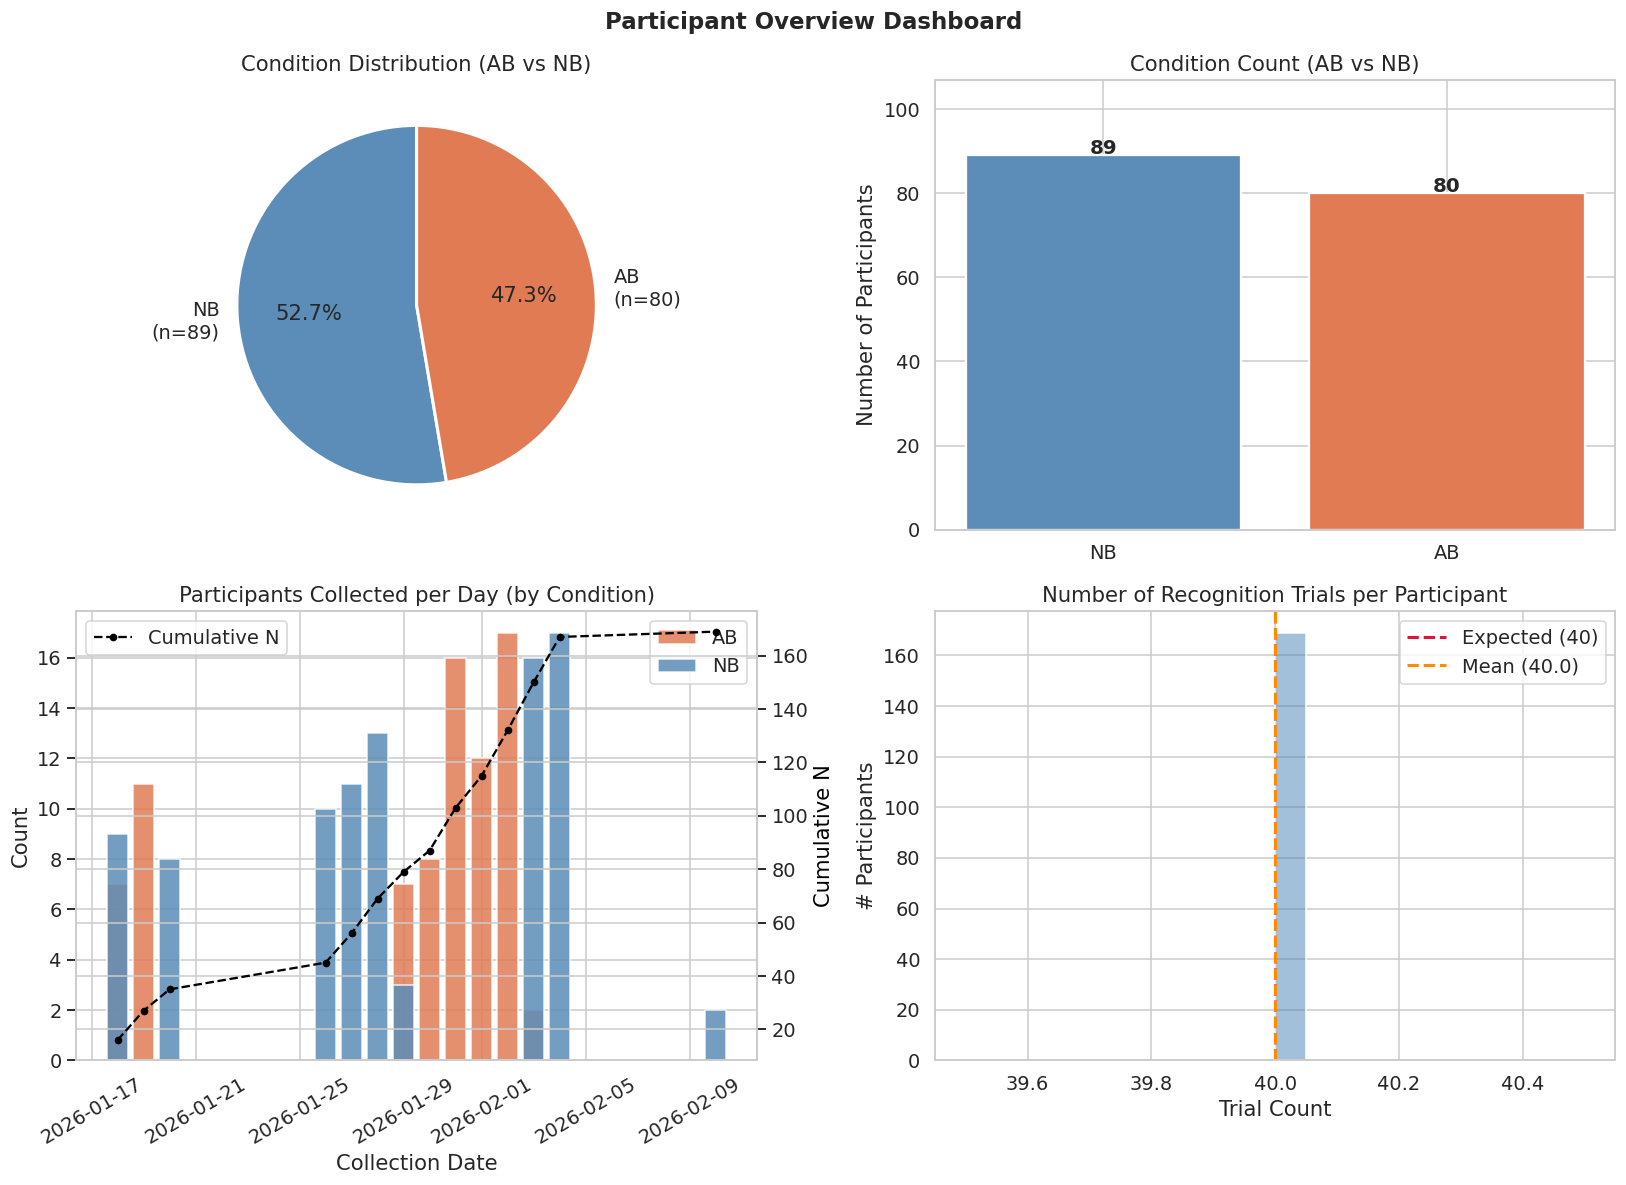

Figure saved: demographics_participant_overview.png


In [18]:

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Participant Overview Dashboard', fontsize=15, fontweight='bold')

# ── 1. Condition split ── pie chart ───────────────────────────────────────
cond_vals = cond_counts.values
cond_lbls = [f"{k}\n(n={v})" for k, v in cond_counts.items()]
wedge_colors = [PALETTE.get(k, '#aaaaaa') for k in cond_counts.index]
axes[0, 0].pie(cond_vals, labels=cond_lbls, colors=wedge_colors,
               autopct='%1.1f%%', startangle=90,
               wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0, 0].set_title('Condition Distribution (AB vs NB)')

# ── 2. Condition split ── bar chart ───────────────────────────────────────
bars = axes[0, 1].bar(cond_counts.index, cond_counts.values,
                      color=wedge_colors, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, cond_counts.values):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                    str(val), ha='center', fontsize=13, fontweight='bold')
axes[0, 1].set_ylabel('Number of Participants')
axes[0, 1].set_title('Condition Count (AB vs NB)')
axes[0, 1].set_ylim(0, cond_counts.max() * 1.2)

# ── 3. Data collection timeline ───────────────────────────────────────────
daily = (ppt_frame.dropna(subset=['collection_date'])
                  .groupby(['collection_date', 'condition'], observed=True)
                  .size().reset_index(name='count'))
if not daily.empty:
    for cond in daily['condition'].unique():
        sub = daily[daily['condition'] == cond].sort_values('collection_date')
        axes[1, 0].bar(sub['collection_date'], sub['count'],
                       label=cond, color=PALETTE.get(cond, '#aaa'),
                       alpha=0.85, edgecolor='white', width=0.8)
    axes[1, 0].set_title('Participants Collected per Day (by Condition)')
    axes[1, 0].set_xlabel('Collection Date')
    axes[1, 0].set_ylabel('Count')
    axes[1, 0].legend()
    axes[1, 0].tick_params(axis='x', rotation=30)
    # Cumulative line
    daily_total = daily.groupby('collection_date')['count'].sum().sort_index().cumsum()
    ax_twin = axes[1, 0].twinx()
    ax_twin.plot(daily_total.index, daily_total.values, 'k--o', ms=4, lw=1.5, label='Cumulative N')
    ax_twin.set_ylabel('Cumulative N', color='black')
    ax_twin.legend(loc='upper left')
else:
    axes[1, 0].text(0.5, 0.5, 'No date data parsed', ha='center', va='center',
                    transform=axes[1, 0].transAxes)

# ── 4. Trials per participant distribution ────────────────────────────────
sns.histplot(ppt_frame['n_trials'], bins=20, kde=True,
             ax=axes[1, 1], color='steelblue', edgecolor='white')
axes[1, 1].axvline(40, color='crimson', ls='--', lw=2, label='Expected (40)')
axes[1, 1].axvline(ppt_frame['n_trials'].mean(), color='darkorange',
                   ls='--', lw=2, label=f"Mean ({ppt_frame['n_trials'].mean():.1f})")
axes[1, 1].set_title('Number of Recognition Trials per Participant')
axes[1, 1].set_xlabel('Trial Count')
axes[1, 1].set_ylabel('# Participants')
axes[1, 1].legend()

plt.tight_layout()
plt.savefig('demographics_participant_overview.png', dpi=140, bbox_inches='tight')
plt.show()
print("Figure saved: demographics_participant_overview.png")


### 4c. Real Participant Demographics (Age, Gender, Handedness, Vision, Caffeine, Alcohol)

The code below looks for a file called **`BRSM dataset/demographics_actual.csv`** with columns:

| `subject_id` | `age` | `gender` | `handedness` | `vision` | `caffeine_2h` | `alcohol_smoke_12h` |
|---|---|---|---|---|---|---|
| sub100 | 21 | Male | Right | Normal | No | No |
| sub101 | 19 | Female | Right | Corrected | Yes | No |
| … | … | … | … | … | … | … |

If the file is not present yet, the cells below will simulate example data so the plots still render — simply replace the simulated frame with the real CSV when it becomes available.


In [19]:

import os, re
import numpy as np
import pandas as pd

DEMO_CSV = os.path.join(DATASET_ROOT, 'demographics_actual.csv')

USING_REAL_DATA = False

if os.path.exists(DEMO_CSV):
    df_actual_demo = pd.read_csv(DEMO_CSV)
    df_actual_demo['subject_id'] = df_actual_demo['subject_id'].astype(str).str.lower().str.strip()
    USING_REAL_DATA = True
    print(f"✓ Loaded real demographics from {DEMO_CSV}")
    print(f"  Shape: {df_actual_demo.shape}")
    print(f"  Columns: {list(df_actual_demo.columns)}")
else:
    print("⚠  demographics_actual.csv not found — using SIMULATED data for plot demonstration.")
    print("   Replace df_actual_demo with a real CSV to get accurate distributions.\n")

    rng = np.random.default_rng(42)
    subs = ppt_frame['subject_id'].tolist()
    n    = len(subs)

    df_actual_demo = pd.DataFrame({
        'subject_id':        [str(s).lower() for s in subs],
        'condition':         ppt_frame['condition'].tolist(),
        'age':               rng.integers(18, 35, size=n),           # typical undergrad pool
        'gender':            rng.choice(['Male', 'Female', 'Non-binary'], size=n,
                                        p=[0.45, 0.50, 0.05]),
        'handedness':        rng.choice(['Right', 'Left', 'Ambidextrous'], size=n,
                                        p=[0.88, 0.10, 0.02]),
        'vision':            rng.choice(['Normal', 'Corrected-to-normal', 'Corrected'],
                                        size=n, p=[0.55, 0.35, 0.10]),
        'caffeine_2h':       rng.choice(['No', 'Yes'], size=n, p=[0.72, 0.28]),
        'alcohol_smoke_12h': rng.choice(['No', 'Yes'], size=n, p=[0.85, 0.15]),
    })

    # Make sure the sim Age follows expected college-age distribution
    df_actual_demo['age'] = rng.normal(loc=21.5, scale=2.5, size=n).clip(18, 45).astype(int)

print(f"\nParticipants with demographics: {len(df_actual_demo)}")
print(df_actual_demo.head())


⚠  demographics_actual.csv not found — using SIMULATED data for plot demonstration.
   Replace df_actual_demo with a real CSV to get accurate distributions.


Participants with demographics: 169
  subject_id condition  age  gender handedness               vision  \
0     sub100        AB   22    Male      Right               Normal   
1     sub101        AB   18  Female      Right  Corrected-to-normal   
2     sub102        AB   22  Female      Right  Corrected-to-normal   
3     sub103        AB   21    Male      Right               Normal   
4     sub104        AB   21  Female      Right  Corrected-to-normal   

  caffeine_2h alcohol_smoke_12h  
0          No                No  
1          No                No  
2          No                No  
3          No               Yes  
4          No                No  


### 4d. Age Distribution

Age Descriptive Statistics
  N       : 169
  Mean    : 21.26 years
  Median  : 21.0 years
  SD      : 2.12
  Range   : 18 – 27 years


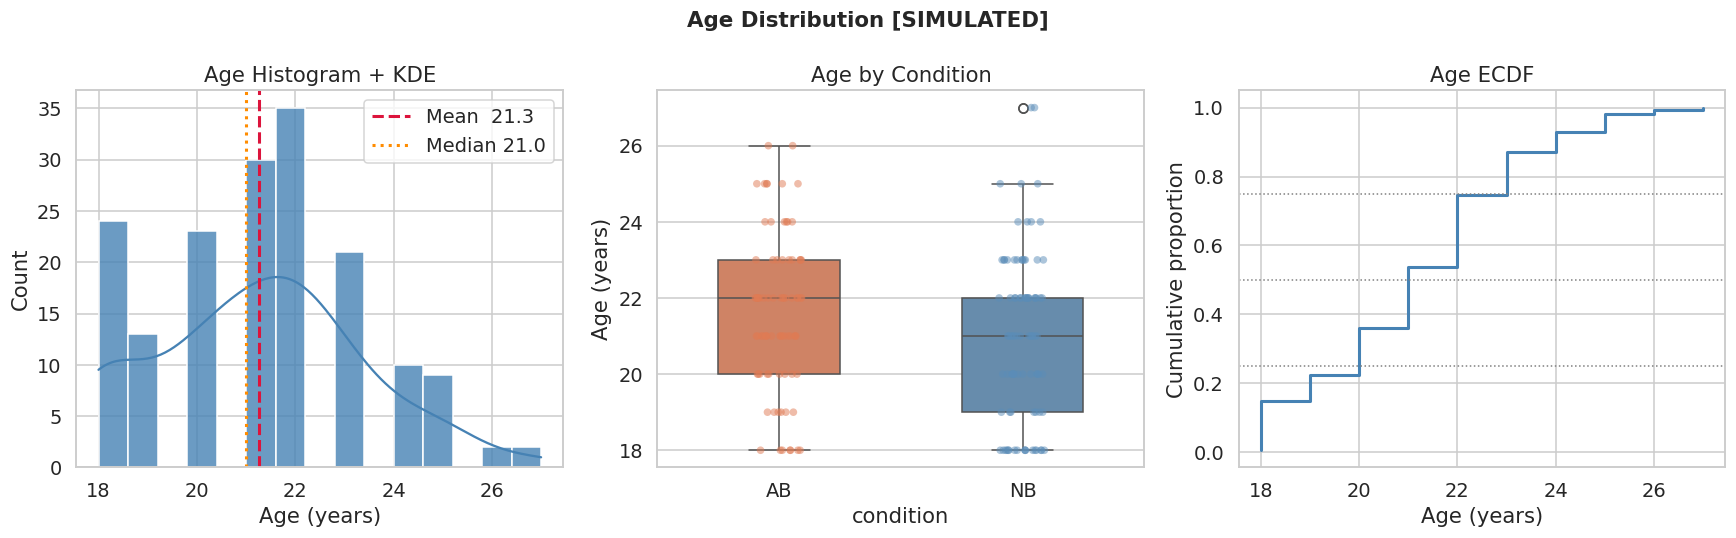

Figure saved: demographics_age.png


In [20]:

age_col = pd.to_numeric(df_actual_demo['age'], errors='coerce').dropna()

age_mean   = age_col.mean()
age_median = age_col.median()
age_std    = age_col.std()
age_min    = age_col.min()
age_max    = age_col.max()

print("Age Descriptive Statistics")
print(f"  N       : {len(age_col)}")
print(f"  Mean    : {age_mean:.2f} years")
print(f"  Median  : {age_median:.1f} years")
print(f"  SD      : {age_std:.2f}")
print(f"  Range   : {age_min:.0f} – {age_max:.0f} years")

suffix = " [SIMULATED]" if not USING_REAL_DATA else ""

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Age Distribution{suffix}', fontsize=14, fontweight='bold')

# ── Histogram + KDE ──────────────────────────────────────────────────────
sns.histplot(age_col, bins=15, kde=True, ax=axes[0],
             color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(age_mean,   color='crimson',     lw=2, ls='--', label=f'Mean  {age_mean:.1f}')
axes[0].axvline(age_median, color='darkorange',  lw=2, ls=':',  label=f'Median {age_median:.1f}')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Histogram + KDE')
axes[0].legend()

# ── Box-and-whisker by condition ──────────────────────────────────────────
if 'condition' in df_actual_demo.columns:
    df_actual_demo['age_num'] = pd.to_numeric(df_actual_demo['age'], errors='coerce')
    sns.boxplot(data=df_actual_demo, x='condition', y='age_num', palette=PALETTE,
                order=['AB', 'NB'], ax=axes[1], width=0.5)
    sns.stripplot(data=df_actual_demo, x='condition', y='age_num', palette=PALETTE,
                  order=['AB', 'NB'], ax=axes[1], jitter=True, alpha=0.5, size=5)
    axes[1].set_title('Age by Condition')
    axes[1].set_ylabel('Age (years)')
else:
    axes[1].axis('off')
    axes[1].text(0.5, 0.5, 'No condition data\nto split by', ha='center', va='center',
                 transform=axes[1].transAxes)

# ── Cumulative distribution (ECDF) ────────────────────────────────────────
sorted_ages = np.sort(age_col)
ecdf_y      = np.arange(1, len(sorted_ages) + 1) / len(sorted_ages)
axes[2].step(sorted_ages, ecdf_y, color='steelblue', lw=2)
axes[2].axhline(0.25, color='gray', ls=':', lw=1)
axes[2].axhline(0.50, color='gray', ls=':', lw=1)
axes[2].axhline(0.75, color='gray', ls=':', lw=1)
axes[2].set_xlabel('Age (years)')
axes[2].set_ylabel('Cumulative proportion')
axes[2].set_title('Age ECDF')

plt.tight_layout()
plt.savefig('demographics_age.png', dpi=140, bbox_inches='tight')
plt.show()
print("Figure saved: demographics_age.png")


### 4e. Gender Distribution

Gender distribution:
  Female                n= 85  (50.3%)
  Male                  n= 76  (45.0%)
  Non-binary            n=  8  (4.7%)


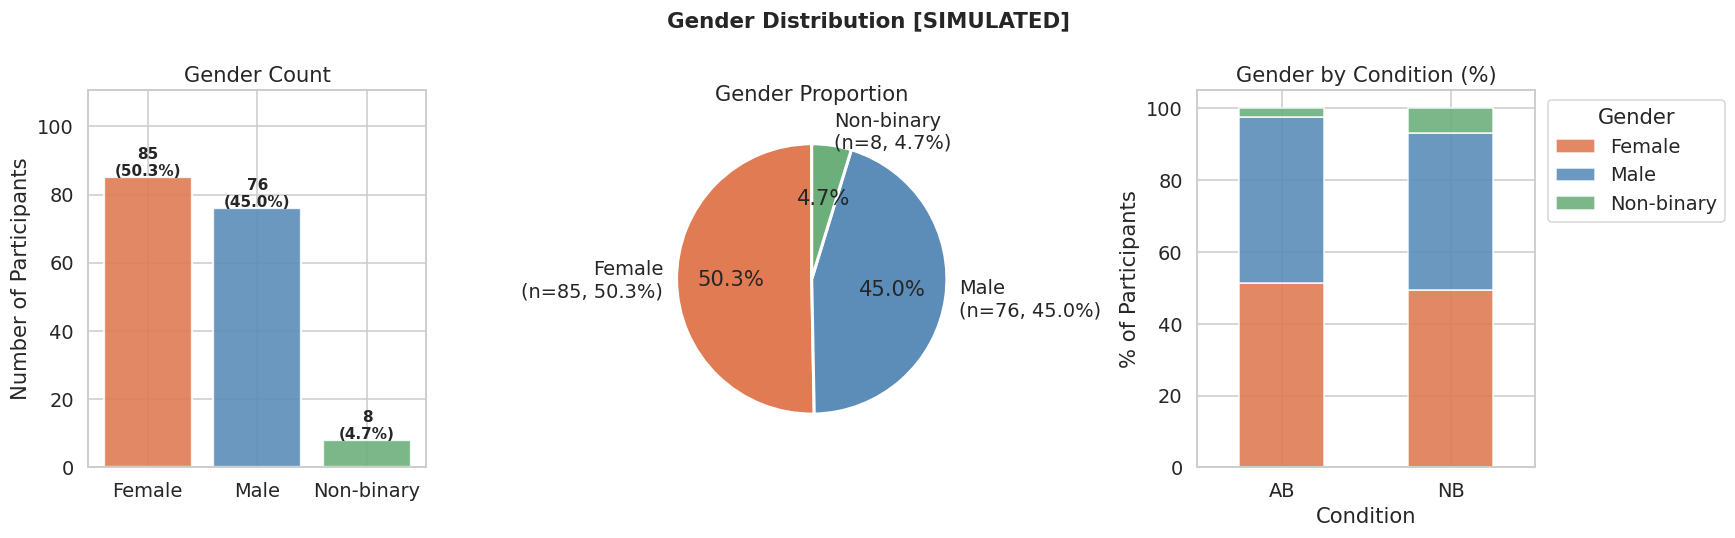

Figure saved: demographics_gender.png


In [21]:

gender_counts = df_actual_demo['gender'].value_counts()
gender_pct    = (gender_counts / gender_counts.sum() * 100).round(1)

print("Gender distribution:")
for g, n_g, pct_g in zip(gender_counts.index, gender_counts.values, gender_pct.values):
    print(f"  {g:20s}  n={n_g:3d}  ({pct_g}%)")

GENDER_COLORS = {'Male': '#5B8DB8', 'Female': '#E07B54',
                 'Non-binary': '#6DAF7B', 'Other': '#C9A96E',
                 'Prefer not to say': '#B0B0B0'}
g_colors = [GENDER_COLORS.get(g, '#aaaaaa') for g in gender_counts.index]

suffix = " [SIMULATED]" if not USING_REAL_DATA else ""
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Gender Distribution{suffix}', fontsize=14, fontweight='bold')

# ── Bar chart ──────────────────────────────────────────────────────────────
bars = axes[0].bar(gender_counts.index, gender_counts.values,
                   color=g_colors, edgecolor='white', linewidth=1.5, alpha=0.9)
for bar, val, pct in zip(bars, gender_counts.values, gender_pct.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.4,
                 f'{val}\n({pct}%)', ha='center', fontsize=10, fontweight='bold')
axes[0].set_ylabel('Number of Participants')
axes[0].set_title('Gender Count')
axes[0].set_ylim(0, gender_counts.max() * 1.3)

# ── Pie chart ──────────────────────────────────────────────────────────────
axes[1].pie(gender_counts.values,
            labels=[f"{g}\n(n={v}, {p}%)" for g, v, p in
                    zip(gender_counts.index, gender_counts.values, gender_pct.values)],
            colors=g_colors,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Gender Proportion')

# ── Gender × Condition stacked bar ────────────────────────────────────────
if 'condition' in df_actual_demo.columns:
    cross = pd.crosstab(df_actual_demo['condition'], df_actual_demo['gender'])
    cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100
    cross_pct.plot(kind='bar', stacked=True, ax=axes[2],
                   color=[GENDER_COLORS.get(c, '#aaa') for c in cross_pct.columns],
                   edgecolor='white', alpha=0.9)
    axes[2].set_title('Gender by Condition (%)')
    axes[2].set_ylabel('% of Participants')
    axes[2].set_xlabel('Condition')
    axes[2].tick_params(axis='x', rotation=0)
    axes[2].legend(title='Gender', bbox_to_anchor=(1.01, 1), loc='upper left')
else:
    axes[2].axis('off')

plt.tight_layout()
plt.savefig('demographics_gender.png', dpi=140, bbox_inches='tight')
plt.show()
print("Figure saved: demographics_gender.png")


### 4f. Handedness, Vision, Caffeine & Alcohol Distributions

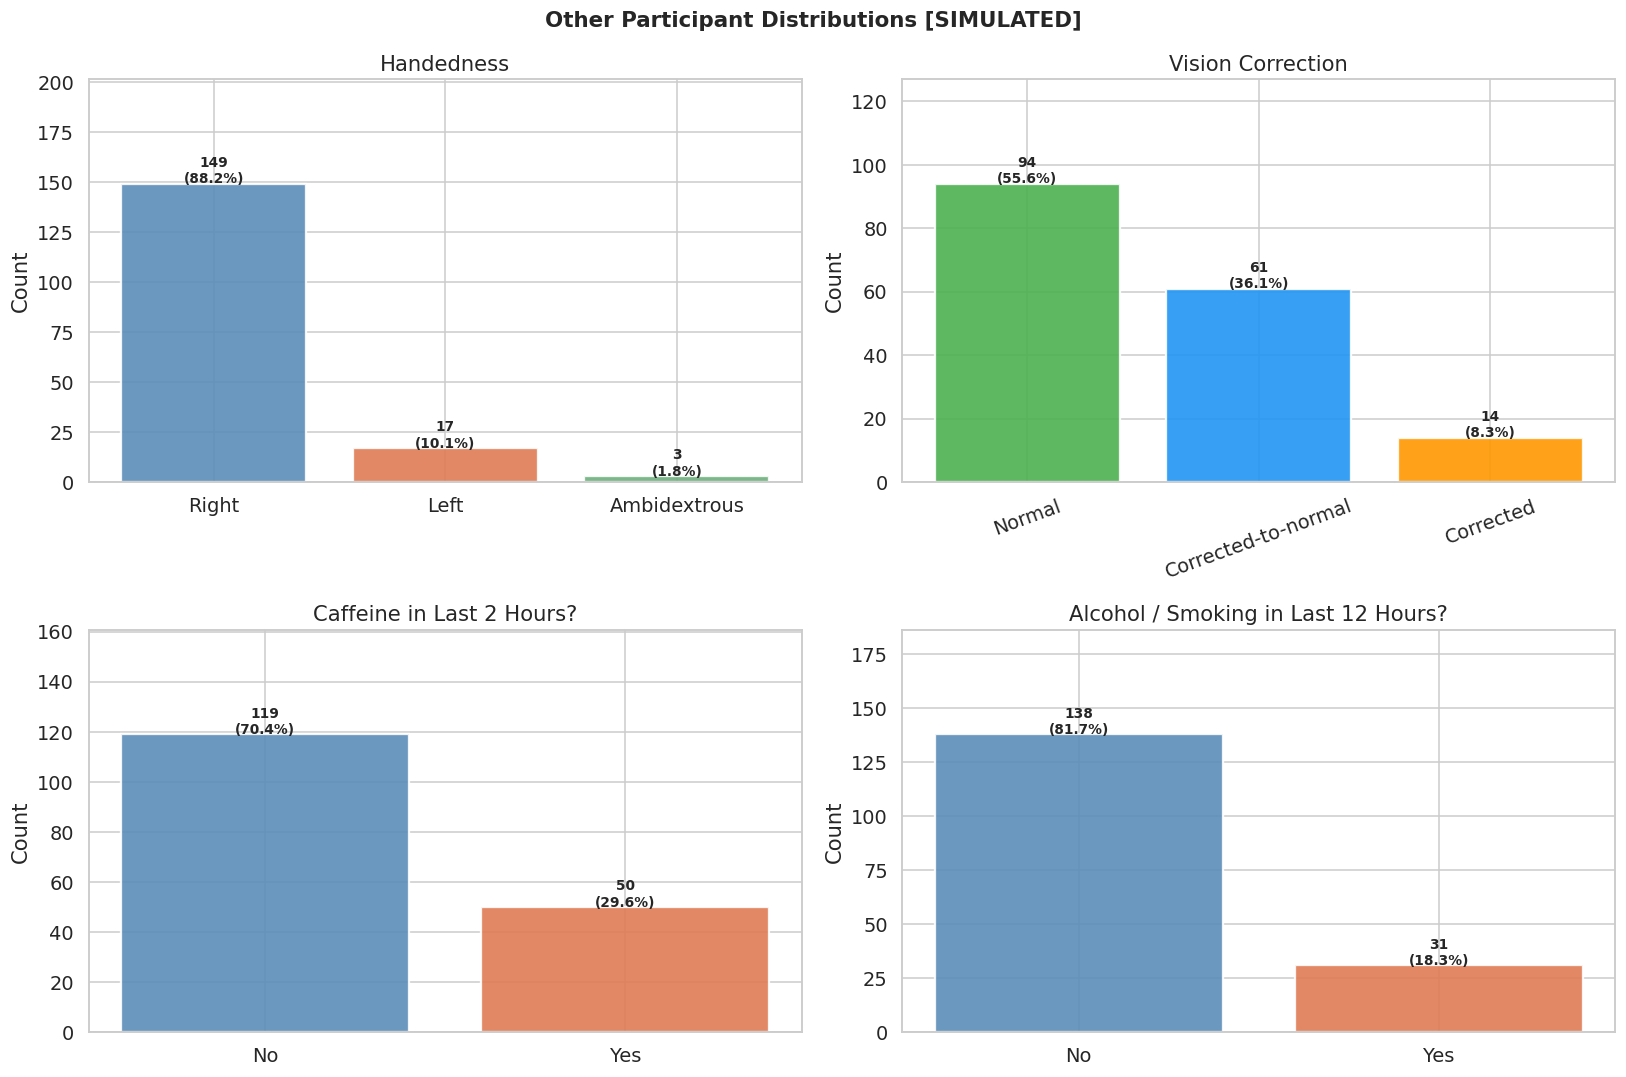

Figure saved: demographics_other.png

── Summary Counts ────────────────────────────────────────────

Handedness:
  Right                           149  (88.2%)
  Left                             17  (10.1%)
  Ambidextrous                      3  (1.8%)

Vision:
  Normal                           94  (55.6%)
  Corrected-to-normal              61  (36.1%)
  Corrected                        14  (8.3%)

Caffeine 2h:
  No                              119  (70.4%)
  Yes                              50  (29.6%)

Alcohol/Smoke 12h:
  No                              138  (81.7%)
  Yes                              31  (18.3%)


In [22]:

suffix = " [SIMULATED]" if not USING_REAL_DATA else ""

# ── Colour palettes per variable ──────────────────────────────────────────
HAND_COLORS = {'Right': '#5B8DB8', 'Left': '#E07B54', 'Ambidextrous': '#6DAF7B'}
VIS_COLORS  = {'Normal': '#4CAF50', 'Corrected-to-normal': '#2196F3',
               'Corrected': '#FF9800', 'Impaired': '#F44336'}
YN_COLORS   = {'No': '#5B8DB8', 'Yes': '#E07B54'}

def plot_categorical_dist(ax, series, title, colors_map, rotate=False):
    vc  = series.value_counts()
    pct = (vc / vc.sum() * 100).round(1)
    cols = [colors_map.get(k, '#aaaaaa') for k in vc.index]
    bars = ax.bar(vc.index, vc.values, color=cols, edgecolor='white',
                  linewidth=1.5, alpha=0.9)
    for bar, val, p in zip(bars, vc.values, pct.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{val}\n({p}%)', ha='center', fontsize=9, fontweight='bold')
    ax.set_title(title)
    ax.set_ylabel('Count')
    ax.set_ylim(0, vc.max() * 1.35)
    if rotate:
        ax.tick_params(axis='x', rotation=20)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle(f'Other Participant Distributions{suffix}', fontsize=14, fontweight='bold')

plot_categorical_dist(axes[0, 0], df_actual_demo['handedness'],
                      'Handedness', HAND_COLORS)
plot_categorical_dist(axes[0, 1], df_actual_demo['vision'],
                      'Vision Correction', VIS_COLORS, rotate=True)
plot_categorical_dist(axes[1, 0], df_actual_demo['caffeine_2h'],
                      'Caffeine in Last 2 Hours?', YN_COLORS)
plot_categorical_dist(axes[1, 1], df_actual_demo['alcohol_smoke_12h'],
                      'Alcohol / Smoking in Last 12 Hours?', YN_COLORS)

plt.tight_layout()
plt.savefig('demographics_other.png', dpi=140, bbox_inches='tight')
plt.show()
print("Figure saved: demographics_other.png")

# ── Summary table ─────────────────────────────────────────────────────────
print("\n── Summary Counts ────────────────────────────────────────────")
for col, label in [('handedness','Handedness'), ('vision','Vision'),
                   ('caffeine_2h','Caffeine 2h'), ('alcohol_smoke_12h','Alcohol/Smoke 12h')]:
    vc = df_actual_demo[col].value_counts()
    print(f"\n{label}:")
    for k, v in vc.items():
        print(f"  {k:30s}  {v:3d}  ({v/len(df_actual_demo)*100:.1f}%)")


### 4g. Combined Demographics Summary Dashboard

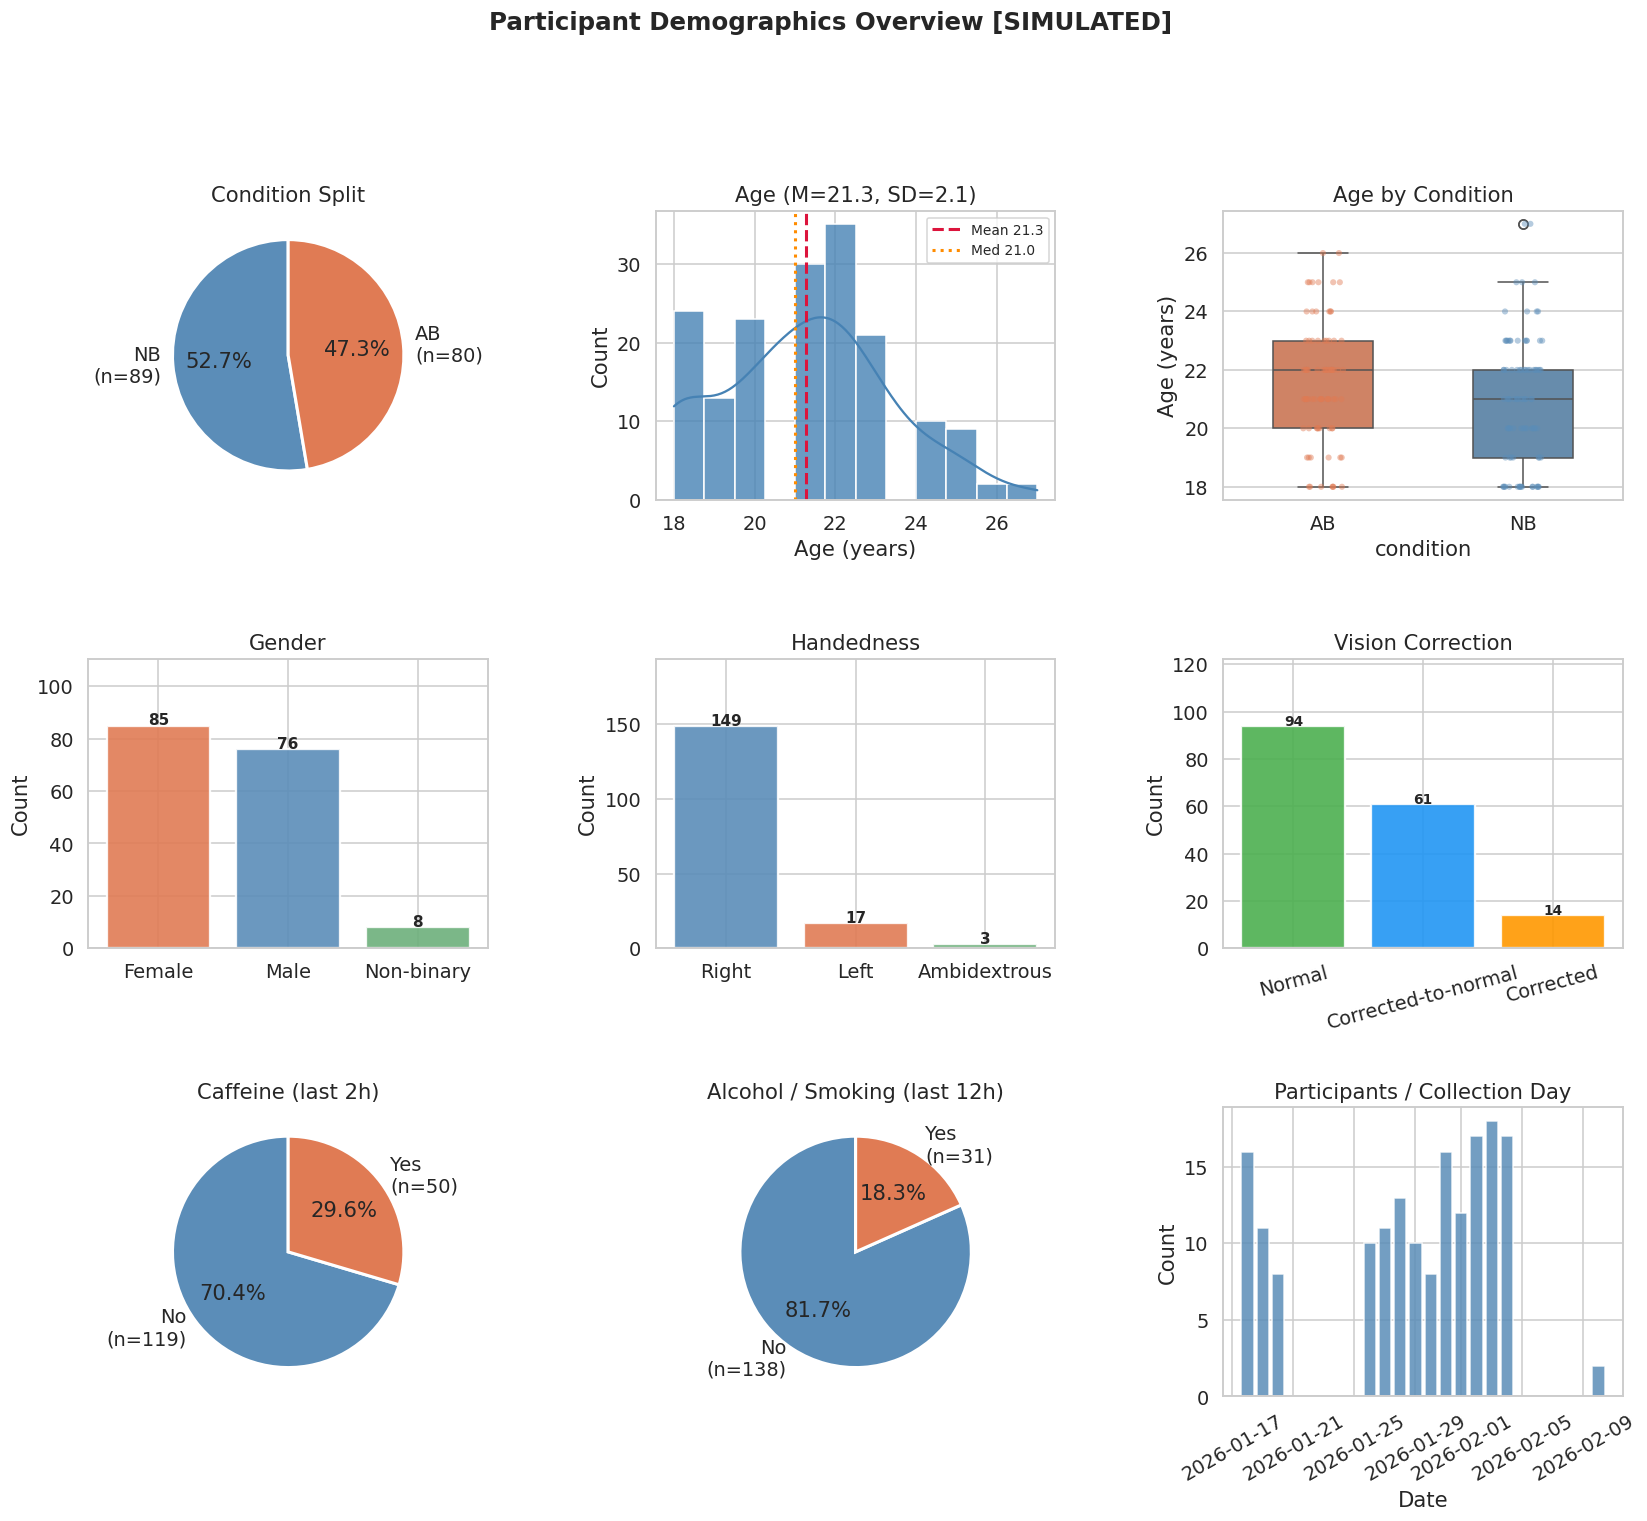

Dashboard saved: demographics_combined_dashboard.png


In [23]:

suffix = " [SIMULATED]" if not USING_REAL_DATA else ""
df_actual_demo['age_num'] = pd.to_numeric(df_actual_demo['age'], errors='coerce')

fig = plt.figure(figsize=(18, 14))
fig.suptitle(f'Participant Demographics Overview{suffix}',
             fontsize=16, fontweight='bold', y=1.01)

gs = fig.add_gridspec(3, 3, hspace=0.55, wspace=0.42)

# ── Row 1, col 0: Condition pie ──────────────────────────────────────────
ax_cond = fig.add_subplot(gs[0, 0])
cond_c  = df_actual_demo['condition'].value_counts()
ax_cond.pie(cond_c.values,
            labels=[f"{k}\n(n={v})" for k,v in cond_c.items()],
            colors=[PALETTE.get(k,'#aaa') for k in cond_c.index],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
ax_cond.set_title('Condition Split')

# ── Row 1, col 1: Age histogram ──────────────────────────────────────────
ax_age = fig.add_subplot(gs[0, 1])
age_data = df_actual_demo['age_num'].dropna()
sns.histplot(age_data, bins=12, kde=True, ax=ax_age,
             color='steelblue', edgecolor='white', alpha=0.8)
ax_age.axvline(age_data.mean(), color='crimson', lw=2, ls='--',
               label=f"Mean {age_data.mean():.1f}")
ax_age.axvline(age_data.median(), color='darkorange', lw=2, ls=':',
               label=f"Med {age_data.median():.1f}")
ax_age.set_title(f'Age (M={age_data.mean():.1f}, SD={age_data.std():.1f})')
ax_age.set_xlabel('Age (years)')
ax_age.set_ylabel('Count')
ax_age.legend(fontsize=9)

# ── Row 1, col 2: Age by condition ───────────────────────────────────────
ax_agec = fig.add_subplot(gs[0, 2])
sns.boxplot(data=df_actual_demo, x='condition', y='age_num', palette=PALETTE,
            order=['AB','NB'], ax=ax_agec, width=0.5)
sns.stripplot(data=df_actual_demo, x='condition', y='age_num', palette=PALETTE,
              order=['AB','NB'], ax=ax_agec, jitter=True, alpha=0.45, size=4)
ax_agec.set_title('Age by Condition')
ax_agec.set_ylabel('Age (years)')

# ── Row 2, col 0: Gender bar ─────────────────────────────────────────────
ax_gen = fig.add_subplot(gs[1, 0])
gen_c  = df_actual_demo['gender'].value_counts()
bars   = ax_gen.bar(gen_c.index, gen_c.values,
                    color=[GENDER_COLORS.get(g,'#aaa') for g in gen_c.index],
                    edgecolor='white', linewidth=1.5, alpha=0.9)
for bar, val in zip(bars, gen_c.values):
    ax_gen.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(val), ha='center', fontsize=10, fontweight='bold')
ax_gen.set_title('Gender')
ax_gen.set_ylabel('Count')
ax_gen.set_ylim(0, gen_c.max() * 1.3)

# ── Row 2, col 1: Handedness bar ─────────────────────────────────────────
ax_hand = fig.add_subplot(gs[1, 1])
hand_c  = df_actual_demo['handedness'].value_counts()
bars2   = ax_hand.bar(hand_c.index, hand_c.values,
                      color=[HAND_COLORS.get(h,'#aaa') for h in hand_c.index],
                      edgecolor='white', linewidth=1.5, alpha=0.9)
for bar, val in zip(bars2, hand_c.values):
    ax_hand.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 str(val), ha='center', fontsize=10, fontweight='bold')
ax_hand.set_title('Handedness')
ax_hand.set_ylabel('Count')
ax_hand.set_ylim(0, hand_c.max() * 1.3)

# ── Row 2, col 2: Vision bar ─────────────────────────────────────────────
ax_vis = fig.add_subplot(gs[1, 2])
vis_c  = df_actual_demo['vision'].value_counts()
bars3  = ax_vis.bar(vis_c.index, vis_c.values,
                    color=[VIS_COLORS.get(v,'#aaa') for v in vis_c.index],
                    edgecolor='white', linewidth=1.5, alpha=0.9)
for bar, val in zip(bars3, vis_c.values):
    ax_vis.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                str(val), ha='center', fontsize=9, fontweight='bold')
ax_vis.set_title('Vision Correction')
ax_vis.set_ylabel('Count')
ax_vis.set_ylim(0, vis_c.max() * 1.3)
ax_vis.tick_params(axis='x', rotation=15)

# ── Row 3, col 0: Caffeine pie ───────────────────────────────────────────
ax_caff = fig.add_subplot(gs[2, 0])
caff_c  = df_actual_demo['caffeine_2h'].value_counts()
ax_caff.pie(caff_c.values,
            labels=[f"{k}\n(n={v})" for k,v in caff_c.items()],
            colors=[YN_COLORS.get(k,'#aaa') for k in caff_c.index],
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(edgecolor='white', linewidth=2))
ax_caff.set_title('Caffeine (last 2h)')

# ── Row 3, col 1: Alcohol/Smoke pie ──────────────────────────────────────
ax_alc = fig.add_subplot(gs[2, 1])
alc_c  = df_actual_demo['alcohol_smoke_12h'].value_counts()
ax_alc.pie(alc_c.values,
           labels=[f"{k}\n(n={v})" for k,v in alc_c.items()],
           colors=[YN_COLORS.get(k,'#aaa') for k in alc_c.index],
           autopct='%1.1f%%', startangle=90,
           wedgeprops=dict(edgecolor='white', linewidth=2))
ax_alc.set_title('Alcohol / Smoking (last 12h)')

# ── Row 3, col 2: Data collection timeline ───────────────────────────────
ax_time = fig.add_subplot(gs[2, 2])
if 'collection_date' in ppt_frame.columns:
    daily2 = (ppt_frame.dropna(subset=['collection_date'])
              .groupby('collection_date').size().sort_index())
    ax_time.bar(daily2.index, daily2.values, color='#5B8DB8',
                alpha=0.85, edgecolor='white', width=0.8)
    ax_time.set_title('Participants / Collection Day')
    ax_time.set_xlabel('Date')
    ax_time.set_ylabel('Count')
    ax_time.tick_params(axis='x', rotation=30)
else:
    ax_time.axis('off')
    ax_time.text(0.5, 0.5, 'No date data', ha='center', va='center',
                 transform=ax_time.transAxes)

plt.savefig('demographics_combined_dashboard.png', dpi=140, bbox_inches='tight')
plt.show()
print("Dashboard saved: demographics_combined_dashboard.png")


## Section 4: Vigilance Check & Participant Exclusions

Vigilance time = `Videos.stopped` − `instruction_2.stopped`.  
Threshold: **> 27.05 minutes** → participant flagged as inattentive and excluded.

In [24]:
VIGILANCE_THRESHOLD_SEC = 27.05 * 60  # 27.05 minutes → seconds

df_vig['videos_started'] = pd.to_numeric(df_vig['videos_started'], errors='coerce')
df_vig['videos_stopped'] = pd.to_numeric(df_vig['videos_stopped'], errors='coerce')
df_vig['vigilance_time_sec'] = df_vig['videos_stopped'] - df_vig['videos_started']
df_vig['vigilance_time_min'] = df_vig['vigilance_time_sec'] / 60
df_vig['flagged_inattentive'] = df_vig['vigilance_time_sec'] > VIGILANCE_THRESHOLD_SEC

print(f"Total participants with vigilance data: {len(df_vig)}")
print(f"Flagged as inattentive (>{VIGILANCE_THRESHOLD_SEC/60:.2f} min): "
      f"{df_vig['flagged_inattentive'].sum()}")
print("\nVigilance time summary (minutes):")
print(df_vig['vigilance_time_min'].describe().round(2))
print("\nFlagged participants:")
print(df_vig[df_vig['flagged_inattentive']][['subject_id','condition','vigilance_time_min']])


Total participants with vigilance data: 169
Flagged as inattentive (>27.05 min): 0

Vigilance time summary (minutes):
count   169.0000
mean      0.4700
std       0.2400
min       0.0200
25%       0.3400
50%       0.5200
75%       0.6200
max       0.9600
Name: vigilance_time_min, dtype: float64

Flagged participants:
Empty DataFrame
Columns: [subject_id, condition, vigilance_time_min]
Index: []


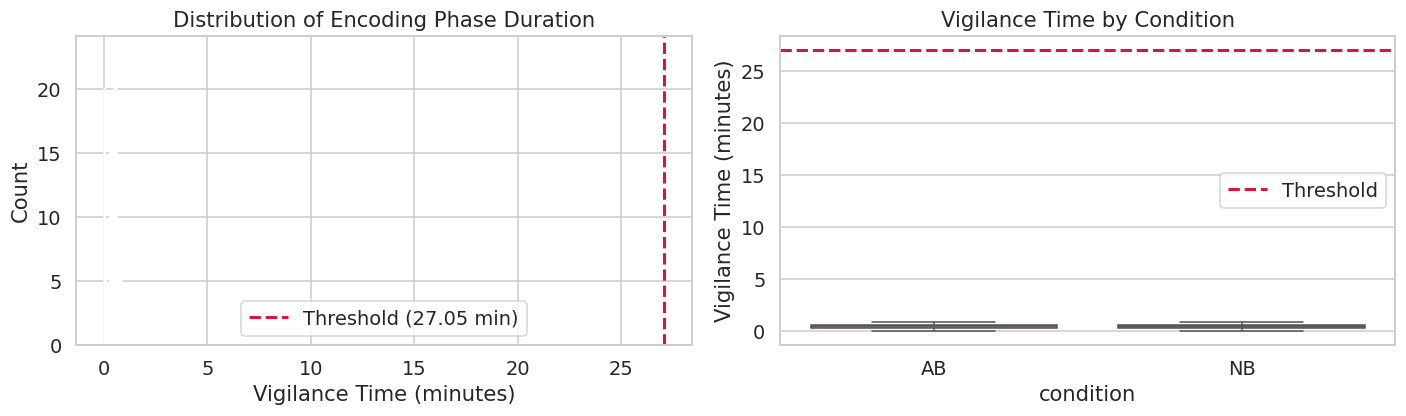

In [25]:
# Visualise vigilance time distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(df_vig['vigilance_time_min'].dropna(), bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(VIGILANCE_THRESHOLD_SEC / 60, color='crimson', lw=2, ls='--', label='Threshold (27.05 min)')
axes[0].set_xlabel('Vigilance Time (minutes)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Encoding Phase Duration')
axes[0].legend()

sns.boxplot(data=df_vig, x='condition', y='vigilance_time_min', palette=PALETTE, ax=axes[1])
axes[1].axhline(VIGILANCE_THRESHOLD_SEC / 60, color='crimson', lw=2, ls='--', label='Threshold')
axes[1].set_title('Vigilance Time by Condition')
axes[1].set_ylabel('Vigilance Time (minutes)')
axes[1].legend()

plt.tight_layout()
plt.show()


In [26]:
# Apply exclusions
excluded_subs = set(df_vig[df_vig['flagged_inattentive']]['subject_id'].tolist())
print(f"Excluded participants: {excluded_subs if excluded_subs else 'None'}")

TRIALS_CLEAN = TRIALS[~TRIALS['subject_id'].isin(excluded_subs)].copy()
print(f"\nTrials after vigilance exclusion: {len(TRIALS_CLEAN):,}")
print(f"Remaining participants: {TRIALS_CLEAN['subject_id'].nunique()}")
print("Condition split:")
print(TRIALS_CLEAN.groupby('condition')['subject_id'].nunique())


Excluded participants: None

Trials after vigilance exclusion: 6,760
Remaining participants: 169
Condition split:
condition
AB    80
NB    89
Name: subject_id, dtype: int64


## Section 5: Handle Missing Values

In [27]:
key_cols = ['accuracy', 'rt', 'confidence', 'target_type', 'movie_id', 'condition', 'subject_id']

missing = TRIALS_CLEAN[key_cols].isnull().sum()
missing_pct = (missing / len(TRIALS_CLEAN) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print("Missing values in key columns:")
print(missing_df)

# Visualise only if there are missing values
cols_with_missing = missing_pct[missing_pct > 0]
if len(cols_with_missing) > 0:
    fig, ax = plt.subplots(figsize=(8, 4))
    cols_with_missing.plot(kind='bar', ax=ax, color='#E07B54', edgecolor='white')
    ax.set_ylabel('Missing %')
    ax.set_title('Missing Value Percentage per Key Column')
    ax.set_ylim(0, max(cols_with_missing.max() + 5, 5))
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("\n✓ No missing values in any key columns — dataset is complete.")


Missing values in key columns:
             Missing Count  Missing %
accuracy                 0     0.0000
rt                       0     0.0000
confidence               0     0.0000
target_type              0     0.0000
movie_id                 0     0.0000
condition                0     0.0000
subject_id               0     0.0000

✓ No missing values in any key columns — dataset is complete.


In [28]:
# Drop rows with missing accuracy, RT, or confidence (required for analysis)
before = len(TRIALS_CLEAN)
TRIALS_CLEAN = TRIALS_CLEAN.dropna(subset=['accuracy', 'rt', 'confidence'])
after = len(TRIALS_CLEAN)
print(f"Rows dropped due to missing accuracy/RT/confidence: {before - after}")
print(f"Remaining trials: {after:,}")


Rows dropped due to missing accuracy/RT/confidence: 0
Remaining trials: 6,760


## Section 6: Remove Duplicates & Data Type Conversion

In [29]:
# Check for duplicates (same participant & movie trial)
dup_mask = TRIALS_CLEAN.duplicated(subset=['subject_id', 'movie_id'], keep=False)
print(f"Duplicate (subject_id, movie_id) pairs: {dup_mask.sum()}")
TRIALS_CLEAN = TRIALS_CLEAN.drop_duplicates(subset=['subject_id', 'movie_id'], keep='first')
print(f"Trials after deduplication: {len(TRIALS_CLEAN):,}")

# ── Type conversions ──────────────────────────────────────────────────────
TRIALS_CLEAN['condition']   = TRIALS_CLEAN['condition'].astype('category')
TRIALS_CLEAN['target_type'] = TRIALS_CLEAN['target_type'].astype('category')
TRIALS_CLEAN['accuracy']    = TRIALS_CLEAN['accuracy'].astype(int)
TRIALS_CLEAN['confidence']  = TRIALS_CLEAN['confidence'].astype(int)
TRIALS_CLEAN['subject_id']  = TRIALS_CLEAN['subject_id'].astype('category')

print("\nFinal dtypes:")
print(TRIALS_CLEAN[['subject_id','condition','target_type','accuracy','rt','confidence']].dtypes)


Duplicate (subject_id, movie_id) pairs: 0
Trials after deduplication: 6,760

Final dtypes:
subject_id     category
condition      category
target_type    category
accuracy          int64
rt              float64
confidence        int64
dtype: object


## Section 7: Outlier Detection — Response Times

Valid RT range: **0.2 s – 30 s**  
We also apply the IQR method to flag statistical outliers.

Hard RT outliers (<0.2s or >30.0s): 14
IQR 3× outliers: 129


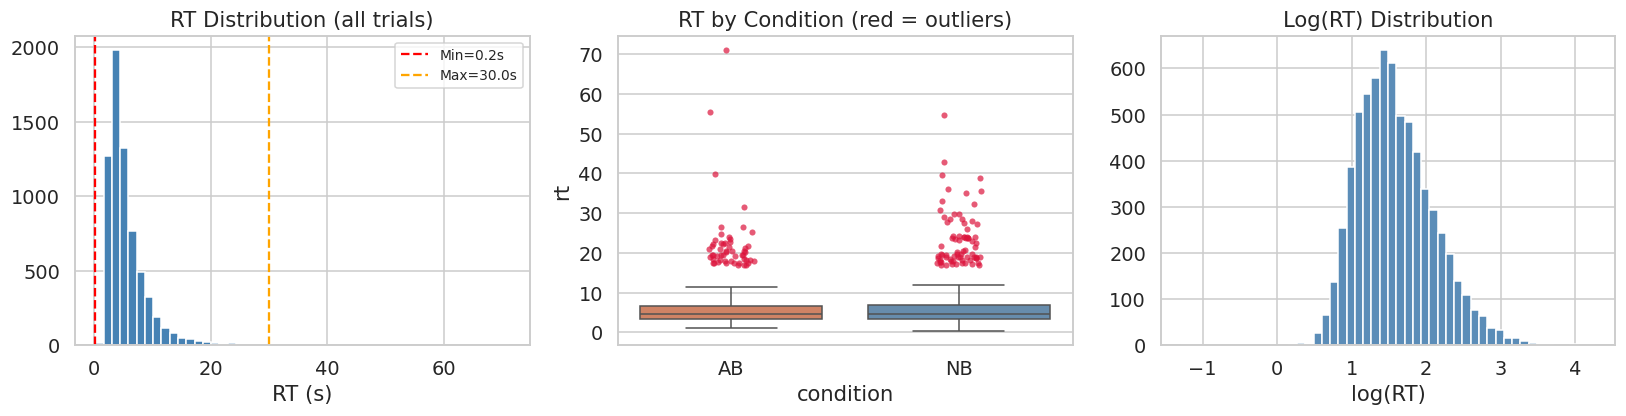


RT summary: mean=5.69s, median=4.62s, SD=3.83s

Trials after removing hard RT outliers: 6,746


In [30]:
RT_MIN, RT_MAX = 0.2, 30.0

# Hard-boundary outliers
hard_out = (TRIALS_CLEAN['rt'] < RT_MIN) | (TRIALS_CLEAN['rt'] > RT_MAX)
print(f"Hard RT outliers (<{RT_MIN}s or >{RT_MAX}s): {hard_out.sum()}")

# IQR outliers
Q1 = TRIALS_CLEAN['rt'].quantile(0.25)
Q3 = TRIALS_CLEAN['rt'].quantile(0.75)
IQR = Q3 - Q1
iqr_out = (TRIALS_CLEAN['rt'] < Q1 - 3 * IQR) | (TRIALS_CLEAN['rt'] > Q3 + 3 * IQR)
print(f"IQR 3× outliers: {iqr_out.sum()}")

# Combined flag (for visualisation; we keep them but flag)
TRIALS_CLEAN['rt_outlier'] = hard_out | iqr_out

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Raw RT distribution
axes[0].hist(TRIALS_CLEAN['rt'], bins=50, color='steelblue', edgecolor='white')
axes[0].axvline(RT_MIN, color='red', ls='--', lw=1.5, label=f'Min={RT_MIN}s')
axes[0].axvline(RT_MAX, color='orange', ls='--', lw=1.5, label=f'Max={RT_MAX}s')
axes[0].set_title('RT Distribution (all trials)')
axes[0].set_xlabel('RT (s)')
axes[0].legend(fontsize=9)

# RT by condition — boxplot
sns.boxplot(data=TRIALS_CLEAN, x='condition', y='rt', palette=PALETTE, ax=axes[1], showfliers=False)
sns.stripplot(data=TRIALS_CLEAN[TRIALS_CLEAN['rt_outlier']], x='condition', y='rt',
              color='crimson', size=4, ax=axes[1], jitter=True, alpha=0.7)
axes[1].set_title('RT by Condition (red = outliers)')

# Log-RT for normality inspection
TRIALS_CLEAN['log_rt'] = np.log(TRIALS_CLEAN['rt'].clip(lower=0.01))
axes[2].hist(TRIALS_CLEAN['log_rt'], bins=50, color='#5B8DB8', edgecolor='white')
axes[2].set_title('Log(RT) Distribution')
axes[2].set_xlabel('log(RT)')

plt.tight_layout()
plt.show()
print(f"\nRT summary: mean={TRIALS_CLEAN['rt'].mean():.2f}s, "
      f"median={TRIALS_CLEAN['rt'].median():.2f}s, SD={TRIALS_CLEAN['rt'].std():.2f}s")

# Remove hard outliers for clean analysis
TRIALS_CLEAN = TRIALS_CLEAN[~hard_out].copy()
print(f"\nTrials after removing hard RT outliers: {len(TRIALS_CLEAN):,}")


## Section 8: Descriptive Statistics by Group

Group-level summaries of accuracy, RT, and confidence for **AB vs NB** conditions.

In [31]:
# ── Per-participant aggregates ──────────────────────────────────────────────
subj_df = TRIALS_CLEAN.groupby(['subject_id', 'condition'], observed=True).agg(
    mean_accuracy = ('accuracy', 'mean'),
    mean_rt       = ('rt', 'mean'),
    median_rt     = ('rt', 'median'),
    mean_conf     = ('confidence', 'mean'),
    n_trials      = ('accuracy', 'count'),
).reset_index()

print("Per-participant summary (first 10 rows):")
print(subj_df.head(10).to_string(index=False))

# ── Group-level descriptives ──────────────────────────────────────────────
grp_desc = subj_df.groupby('condition', observed=True)[['mean_accuracy','mean_rt','mean_conf']].describe().round(3)
print("\nGroup-level descriptive statistics:")
print(grp_desc)


Per-participant summary (first 10 rows):
subject_id condition  mean_accuracy  mean_rt  median_rt  mean_conf  n_trials
    sub100        AB         0.9750   9.4829     8.4794     4.1250        40
    sub101        AB         0.8250   6.0018     5.2424     4.2500        40
    sub102        AB         0.8500   4.7284     4.4396     4.1000        40
    sub103        AB         0.8500   4.3780     3.8732     3.5000        40
    sub104        AB         0.8250   4.0696     3.8757     4.3000        40
    sub105        AB         0.7500   5.8447     5.5605     3.5750        40
    sub106        AB         0.7250   4.7929     3.9174     4.4750        40
    sub107        AB         0.9500   6.2380     4.0894     3.8500        40
    sub108        AB         0.7500   6.0472     4.4417     3.2500        40
    sub109        AB         0.8000   6.2702     5.5218     3.6000        40

Group-level descriptive statistics:
          mean_accuracy                                                   \

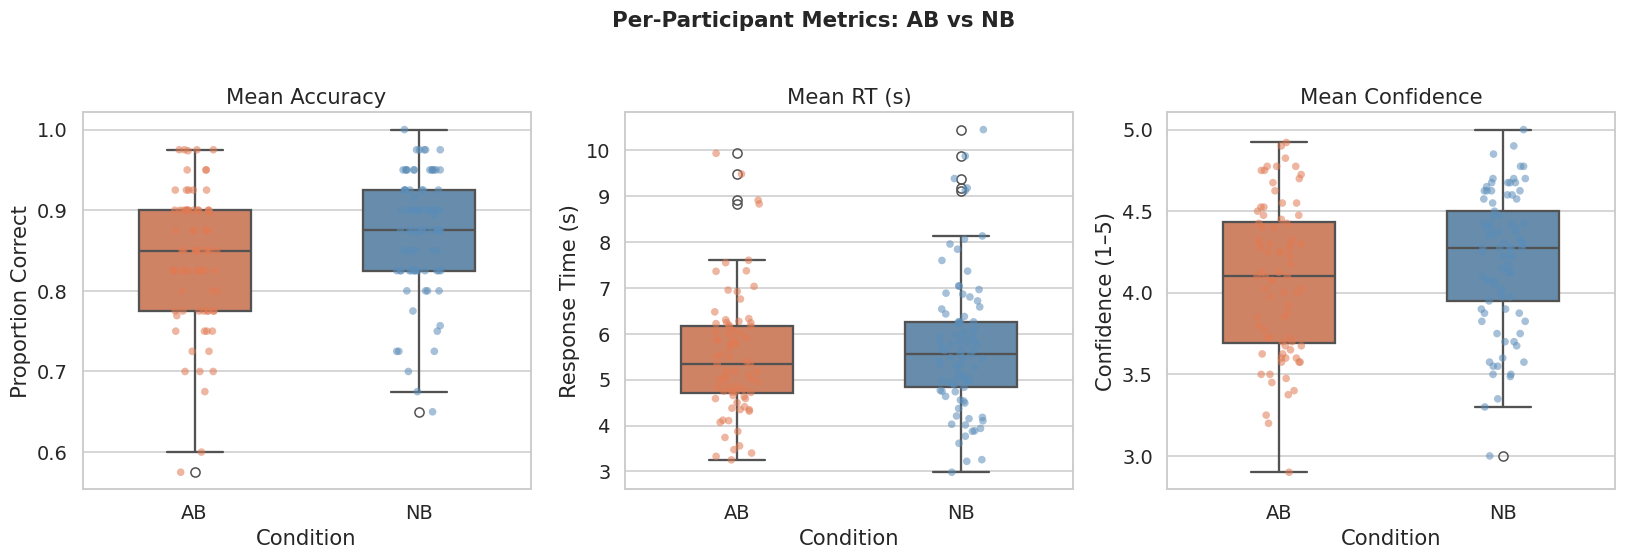

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ('mean_accuracy', 'Mean Accuracy', 'Proportion Correct'),
    ('mean_rt',       'Mean RT (s)',   'Response Time (s)'),
    ('mean_conf',     'Mean Confidence', 'Confidence (1–5)'),
]

for ax, (col, title, ylabel) in zip(axes, metrics):
    sns.boxplot(data=subj_df, x='condition', y=col, palette=PALETTE, ax=ax,
                order=['AB', 'NB'], width=0.5, linewidth=1.5)
    sns.stripplot(data=subj_df, x='condition', y=col, palette=PALETTE, ax=ax,
                  order=['AB', 'NB'], size=5, jitter=True, alpha=0.55, dodge=False)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel('Condition')

plt.suptitle('Per-Participant Metrics: AB vs NB', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Section 9: Recognition Accuracy Analysis

### 9a. Accuracy by Condition (AB vs NB)
### 9b. Accuracy by Target Type (BB vs EM) within each Condition
### 9c. Statistical Tests (t-test / Mann-Whitney U)

In [33]:
# ── 9a. Overall accuracy by condition ─────────────────────────────────────
acc_by_condition = (TRIALS_CLEAN.groupby('condition', observed=True)['accuracy']
                    .agg(['mean', 'std', 'count'])
                    .rename(columns={'mean': 'Mean Accuracy', 'std': 'SD', 'count': 'N Trials'}))
acc_by_condition['SE'] = acc_by_condition['SD'] / np.sqrt(acc_by_condition['N Trials'])
print("Accuracy by Condition:")
print(acc_by_condition.round(4))

# ── 9b. Accuracy by Condition × Target Type ───────────────────────────────
acc_ct = (TRIALS_CLEAN.groupby(['condition', 'target_type'], observed=True)['accuracy']
          .agg(['mean', 'std', 'count'])
          .rename(columns={'mean': 'Mean', 'std': 'SD', 'count': 'N'})
          .reset_index())
acc_ct['SE'] = acc_ct['SD'] / np.sqrt(acc_ct['N'])
print("\nAccuracy by Condition × Target Type:")
print(acc_ct.round(4).to_string(index=False))


Accuracy by Condition:
           Mean Accuracy     SD  N Trials     SE
condition                                       
AB                0.8392 0.3674      3196 0.0065
NB                0.8727 0.3334      3550 0.0056

Accuracy by Condition × Target Type:
condition target_type   Mean     SD    N     SE
       AB          BB 0.8228 0.3820 1597 0.0096
       AB          EM 0.8555 0.3517 1599 0.0088
       NB          BB 0.8609 0.3461 1776 0.0082
       NB          EM 0.8844 0.3198 1774 0.0076


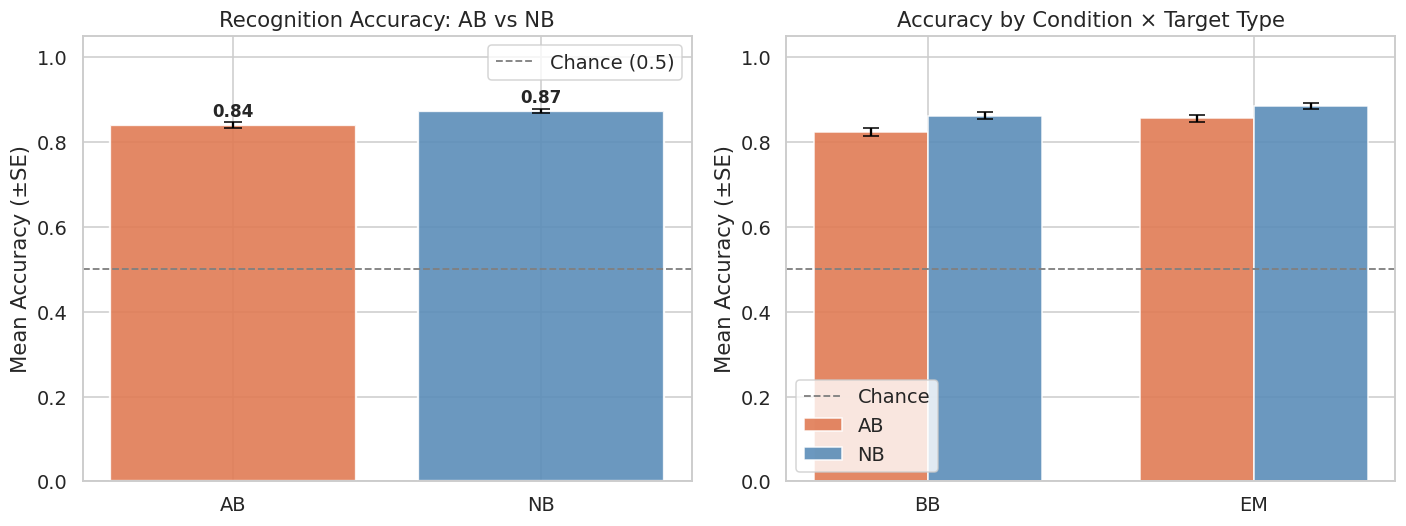

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart: overall accuracy by condition
means = acc_by_condition['Mean Accuracy']
ses   = acc_by_condition['SE']
bars  = axes[0].bar(means.index, means.values, yerr=ses.values,
                    color=[PALETTE[c] for c in means.index],
                    capsize=6, edgecolor='white', linewidth=1.5, alpha=0.9)
axes[0].axhline(0.5, color='gray', ls='--', lw=1.2, label='Chance (0.5)')
axes[0].set_ylabel('Mean Accuracy (±SE)')
axes[0].set_title('Recognition Accuracy: AB vs NB')
axes[0].set_ylim(0, 1.05)
axes[0].legend()
for bar, val in zip(bars, means.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

# Grouped bar: Condition × Target Type
x = np.arange(acc_ct['target_type'].nunique())
target_types = acc_ct['target_type'].unique()
conditions   = acc_ct['condition'].unique()
width = 0.35

for i, cond in enumerate(conditions):
    sub = acc_ct[acc_ct['condition'] == cond].set_index('target_type').reindex(target_types)
    axes[1].bar(x + i*width - width/2, sub['Mean'], width,
                yerr=sub['SE'], capsize=5,
                label=cond, color=PALETTE[cond], alpha=0.9, edgecolor='white')

axes[1].axhline(0.5, color='gray', ls='--', lw=1.2, label='Chance')
axes[1].set_xticks(x)
axes[1].set_xticklabels(target_types)
axes[1].set_ylabel('Mean Accuracy (±SE)')
axes[1].set_title('Accuracy by Condition × Target Type')
axes[1].set_ylim(0, 1.05)
axes[1].legend()

plt.tight_layout()
plt.show()


In [35]:
# ── 9c. Statistical tests on per-participant accuracy ─────────────────────
ab_acc = subj_df[subj_df['condition'] == 'AB']['mean_accuracy']
nb_acc = subj_df[subj_df['condition'] == 'NB']['mean_accuracy']

# Normality check
_, p_ab = shapiro(ab_acc)
_, p_nb = shapiro(nb_acc)
print(f"Shapiro-Wilk normality — AB: p={p_ab:.4f}, NB: p={p_nb:.4f}")

# Choose test based on normality
if p_ab > 0.05 and p_nb > 0.05:
    t_stat, p_val = ttest_ind(ab_acc, nb_acc, equal_var=False)
    test_name = "Welch's t-test"
else:
    t_stat, p_val = mannwhitneyu(ab_acc, nb_acc, alternative='two-sided')
    test_name = "Mann-Whitney U"

# Cohen's d
cohens_d = (ab_acc.mean() - nb_acc.mean()) / np.sqrt((ab_acc.std()**2 + nb_acc.std()**2) / 2)
print(f"\n{test_name}: statistic={t_stat:.4f}, p={p_val:.4f}")
print(f"Effect size (Cohen's d) = {cohens_d:.4f}")
print(f"\nAB mean accuracy: {ab_acc.mean():.4f} ± {ab_acc.std():.4f}")
print(f"NB mean accuracy: {nb_acc.mean():.4f} ± {nb_acc.std():.4f}")


Shapiro-Wilk normality — AB: p=0.0084, NB: p=0.0006

Mann-Whitney U: statistic=2681.5000, p=0.0054
Effect size (Cohen's d) = -0.4327

AB mean accuracy: 0.8393 ± 0.0825
NB mean accuracy: 0.8726 ± 0.0715


## Section 10: Response Time Analysis

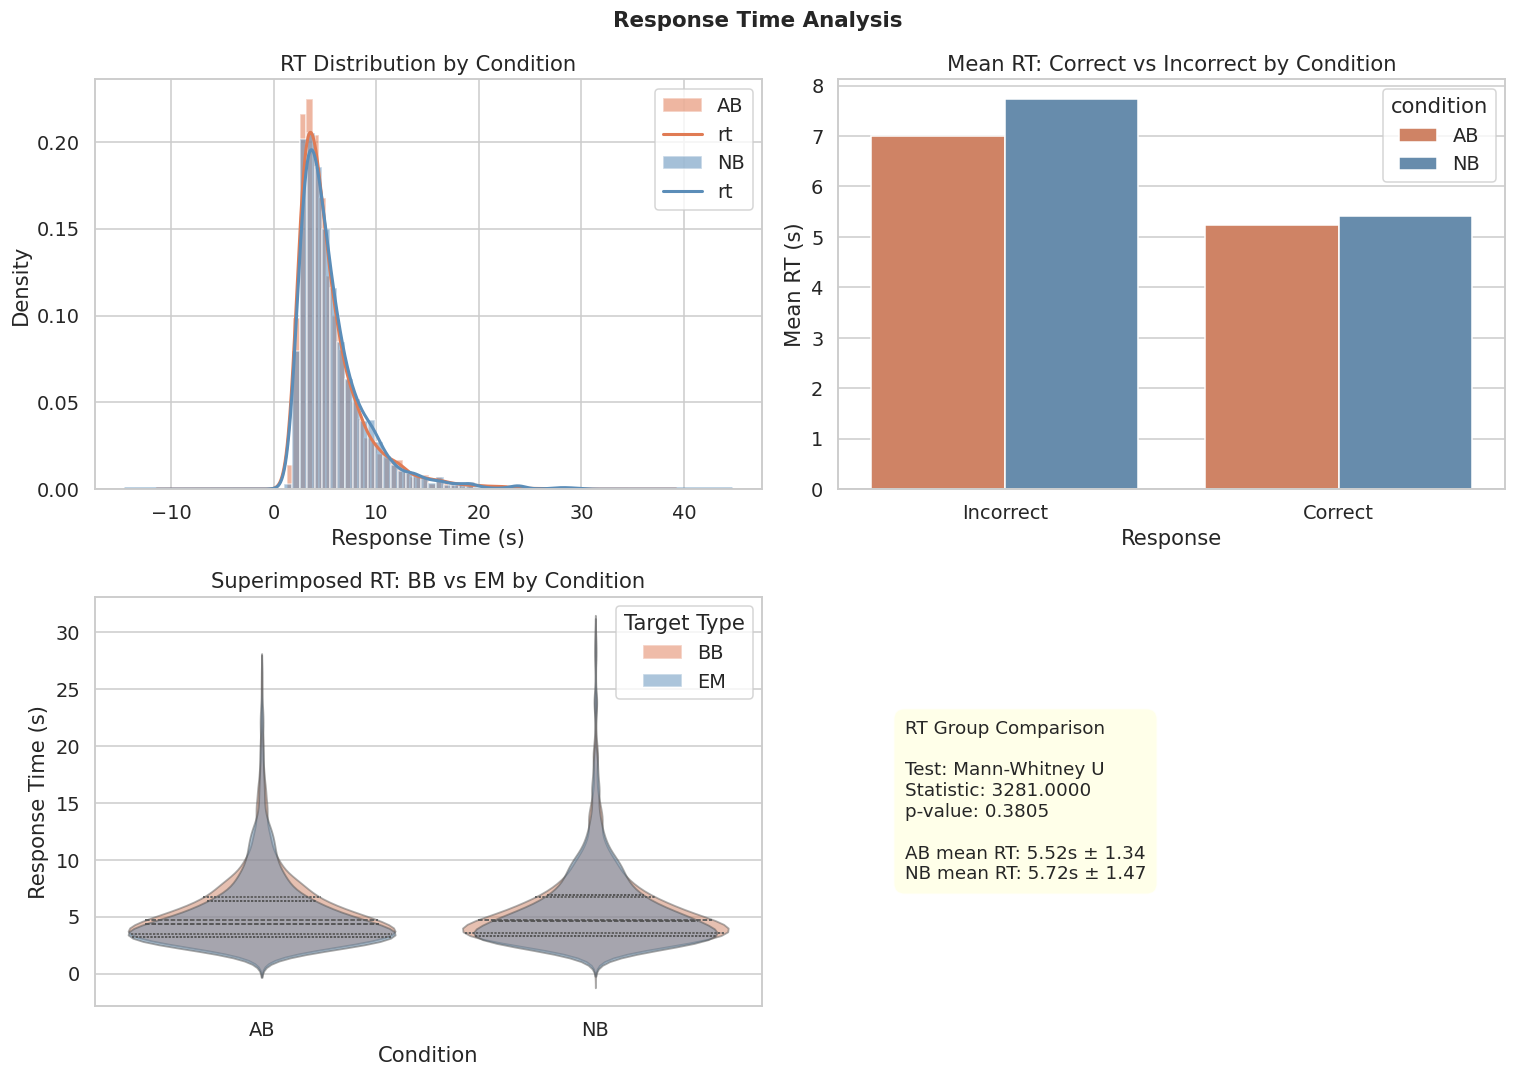

In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# KDE by condition
for cond in ['AB', 'NB']:
    data = TRIALS_CLEAN[TRIALS_CLEAN['condition'] == cond]['rt']
    axes[0, 0].hist(data, bins=40, alpha=0.55, label=cond, color=PALETTE[cond], edgecolor='white', density=True)
    data.plot.kde(ax=axes[0, 0], color=PALETTE[cond], lw=2)
axes[0, 0].set_title('RT Distribution by Condition')
axes[0, 0].set_xlabel('Response Time (s)')
axes[0, 0].legend()

# RT vs Accuracy
rt_acc = TRIALS_CLEAN.groupby(['condition', 'accuracy'], observed=True)['rt'].mean().reset_index()
rt_acc['accuracy_label'] = rt_acc['accuracy'].map({0: 'Incorrect', 1: 'Correct'})
sns.barplot(data=rt_acc, x='accuracy_label', y='rt', hue='condition',
            palette=PALETTE, ax=axes[0, 1], capsize=0.05)
axes[0, 1].set_title('Mean RT: Correct vs Incorrect by Condition')
axes[0, 1].set_ylabel('Mean RT (s)')
axes[0, 1].set_xlabel('Response')

# ==============================================================
# Superimposed RT Violins: BB vs EM by Condition
# ==============================================================
from matplotlib.patches import Patch

bb_data = TRIALS_CLEAN[TRIALS_CLEAN['target_type'] == 'BB']
em_data = TRIALS_CLEAN[TRIALS_CLEAN['target_type'] == 'EM']

BB_COLOR = '#E07B54'
EM_COLOR = '#5B8DB8'

# Plot BB violins first (background layer)
sns.violinplot(data=bb_data, x='condition', y='rt', order=['AB', 'NB'],
               color=BB_COLOR, ax=axes[1, 0], inner='quart', linewidth=1.2)

# Plot EM violins on top (foreground layer)
sns.violinplot(data=em_data, x='condition', y='rt', order=['AB', 'NB'],
               color=EM_COLOR, ax=axes[1, 0], inner='quart', linewidth=1.2)

# Set transparency AFTER plotting so both layers are visible
for collection in axes[1, 0].collections:
    collection.set_alpha(0.5)

axes[1, 0].set_title('Superimposed RT: BB vs EM by Condition')
axes[1, 0].set_ylabel('Response Time (s)')
axes[1, 0].set_xlabel('Condition')

# Custom legend
legend_elements = [Patch(facecolor=BB_COLOR, alpha=0.5, label='BB'),
                   Patch(facecolor=EM_COLOR, alpha=0.5, label='EM')]
axes[1, 0].legend(handles=legend_elements, title='Target Type')

# RT Statistical test
ab_rt = subj_df[subj_df['condition'] == 'AB']['mean_rt']
nb_rt = subj_df[subj_df['condition'] == 'NB']['mean_rt']
_, p_ab_rt = shapiro(ab_rt)
_, p_nb_rt = shapiro(nb_rt)
if p_ab_rt > 0.05 and p_nb_rt > 0.05:
    stat, p = ttest_ind(ab_rt, nb_rt, equal_var=False)
    test_nm = "Welch's t-test"
else:
    stat, p = mannwhitneyu(ab_rt, nb_rt, alternative='two-sided')
    test_nm = "Mann-Whitney U"

axes[1, 1].axis('off')
axes[1, 1].text(0.1, 0.7, f'RT Group Comparison\n\nTest: {test_nm}\nStatistic: {stat:.4f}\np-value: {p:.4f}\n\n'
                f'AB mean RT: {ab_rt.mean():.2f}s ± {ab_rt.std():.2f}\n'
                f'NB mean RT: {nb_rt.mean():.2f}s ± {nb_rt.std():.2f}',
                transform=axes[1, 1].transAxes,
                fontsize=12, verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.6', facecolor='lightyellow', alpha=0.7))

plt.suptitle('Response Time Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## Section 11: Confidence Rating Analysis

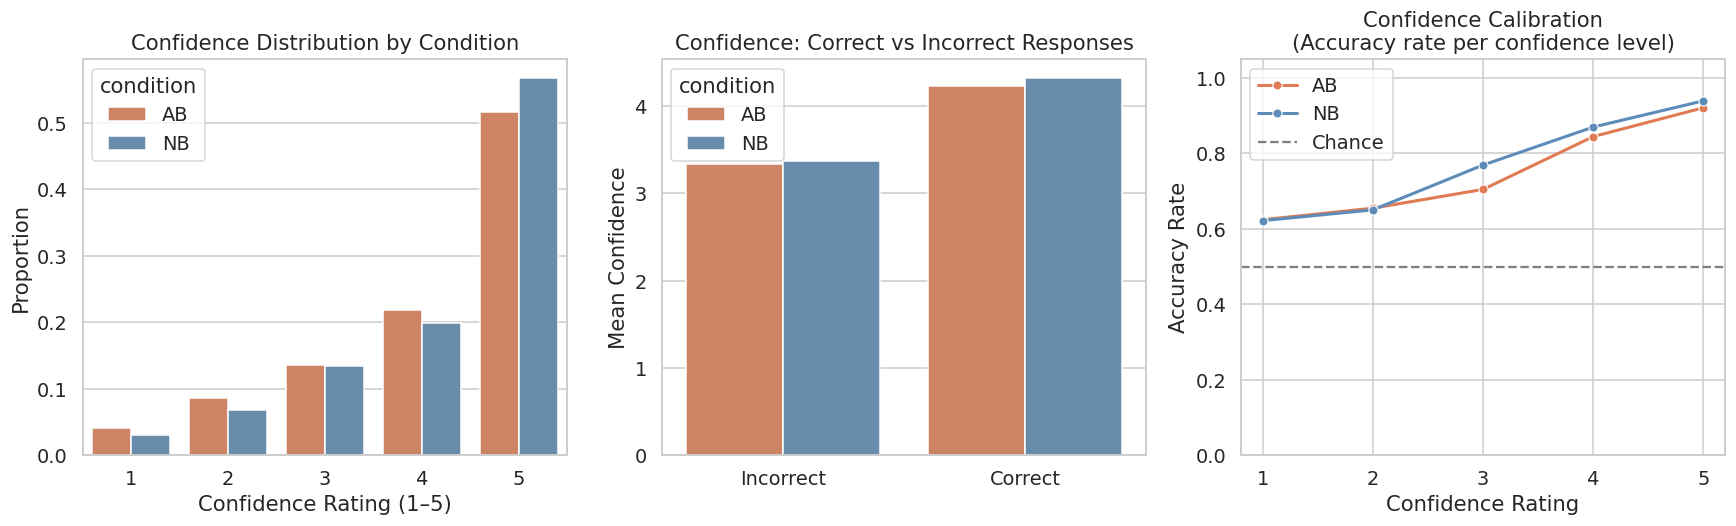

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Confidence distribution by condition
conf_counts = (TRIALS_CLEAN.groupby(['condition', 'confidence'], observed=True)
               .size().reset_index(name='count'))
conf_total  = TRIALS_CLEAN.groupby('condition', observed=True)['confidence'].count().reset_index(name='total')
conf_counts = conf_counts.merge(conf_total, on='condition')
conf_counts['proportion'] = conf_counts['count'] / conf_counts['total']

sns.barplot(data=conf_counts, x='confidence', y='proportion', hue='condition',
            palette=PALETTE, ax=axes[0])
axes[0].set_title('Confidence Distribution by Condition')
axes[0].set_xlabel('Confidence Rating (1–5)')
axes[0].set_ylabel('Proportion')

# Mean confidence per accuracy level
conf_acc = TRIALS_CLEAN.groupby(['accuracy', 'condition'], observed=True)['confidence'].mean().reset_index()
conf_acc['accuracy_label'] = conf_acc['accuracy'].map({0: 'Incorrect', 1: 'Correct'})
sns.barplot(data=conf_acc, x='accuracy_label', y='confidence', hue='condition',
            palette=PALETTE, ax=axes[1], capsize=0.05)
axes[1].set_title('Confidence: Correct vs Incorrect Responses')
axes[1].set_ylabel('Mean Confidence')
axes[1].set_xlabel('')

# Confidence calibration: accuracy rate per confidence level
calib = (TRIALS_CLEAN.groupby(['confidence', 'condition'], observed=True)['accuracy']
         .mean().reset_index())
sns.lineplot(data=calib, x='confidence', y='accuracy', hue='condition',
             palette=PALETTE, marker='o', lw=2, ax=axes[2])
axes[2].axhline(0.5, color='gray', ls='--', label='Chance')
axes[2].set_title('Confidence Calibration\n(Accuracy rate per confidence level)')
axes[2].set_xlabel('Confidence Rating')
axes[2].set_ylabel('Accuracy Rate')
axes[2].set_ylim(0, 1.05)
axes[2].legend()

plt.tight_layout()
plt.show()


## Section 12: Memory Indices — REC & LDI

$$REC = P(\text{"old"} \mid \text{Target}) - P(\text{"old"} \mid \text{Foil})$$

$$LDI = P(\text{"similar"} \mid \text{Lure}) - P(\text{"similar"} \mid \text{Foil})$$

In this dataset:
- **Target** = participant correctly selected the target image → `accuracy == 1`
- **Foil** = novel lure image presented; a "foil hit" is when the participant *incorrectly* chose the lure (`accuracy == 0`)
- **REC** is the bias-corrected hit rate: `P(correct on target) - P(false alarm on lure)`
- **LDI** (lure discrimination) measures high-fidelity mnemonic discrimination — computed as `P(rejecting lure as "similar") - P(rejecting foil as "similar")`. Here we use the analogue: proportion of high-similarity lures correctly rejected vs foils.

In [38]:
# ── Compute REC per participant ────────────────────────────────────────────
# P("old" | Target)  = hit rate = mean accuracy across all trials
# P("old" | Foil)    = false alarm rate = 1 - mean accuracy (chose lure when should have chosen target)
# Note: in a 2AFC design, FA rate = 1 - hit rate at the participant level
# REC = hit_rate - (1 - hit_rate) = 2*hit_rate - 1  (equivalent to d-prime linear proxy)

rec_df = TRIALS_CLEAN.groupby(['subject_id', 'condition'], observed=True).agg(
    hit_rate   = ('accuracy', 'mean'),
    n_trials   = ('accuracy', 'count'),
).reset_index()

rec_df['fa_rate'] = 1 - rec_df['hit_rate']   # in 2AFC: FA = error rate
rec_df['REC']     = rec_df['hit_rate'] - rec_df['fa_rate']  # = 2*hit_rate - 1

print("REC index summary by condition:")
print(rec_df.groupby('condition', observed=True)['REC'].describe().round(4))


REC index summary by condition:
            count   mean    std    min    25%    50%    75%    max
condition                                                         
AB        80.0000 0.6785 0.1649 0.1500 0.5500 0.7000 0.8000 0.9500
NB        89.0000 0.7453 0.1429 0.3000 0.6500 0.7500 0.8500 1.0000


In [39]:
# ── LDI: per target-type discrimination ────────────────────────────────────
# LDI_BB = hit_rate(BB trials) - fa_rate(BB trials)
# LDI_EM = hit_rate(EM trials) - fa_rate(EM trials)
ldi_df = TRIALS_CLEAN.groupby(['subject_id', 'condition', 'target_type'], observed=True).agg(
    hit_rate = ('accuracy', 'mean'),
    n        = ('accuracy', 'count'),
).reset_index()
ldi_df['fa_rate'] = 1 - ldi_df['hit_rate']
ldi_df['LDI']      = ldi_df['hit_rate'] - ldi_df['fa_rate']

# Pivot so BB and EM are columns
ldi_pivot = ldi_df.pivot_table(index=['subject_id', 'condition'], columns='target_type',
                                values='LDI', observed=True).reset_index()
ldi_pivot.columns.name = None
if 'BB' in ldi_pivot.columns and 'EM' in ldi_pivot.columns:
    ldi_pivot = ldi_pivot.rename(columns={'BB': 'LDI_BB', 'EM': 'LDI_EM'})

# Merge into rec_df
rec_full = rec_df.merge(ldi_pivot, on=['subject_id', 'condition'], how='left')
print("Full memory indices dataframe (head):")
print(rec_full.head(8).to_string(index=False))
print("\nLDI_BB by condition:")
print(rec_full.groupby('condition', observed=True)['LDI_BB'].describe().round(4))
print("\nLDI_EM by condition:")
print(rec_full.groupby('condition', observed=True)['LDI_EM'].describe().round(4))


Full memory indices dataframe (head):
subject_id condition  hit_rate  n_trials  fa_rate    REC  LDI_BB  LDI_EM
    sub100        AB    0.9750        40   0.0250 0.9500  1.0000  0.9000
    sub101        AB    0.8250        40   0.1750 0.6500  0.3000  1.0000
    sub102        AB    0.8500        40   0.1500 0.7000  0.6000  0.8000
    sub103        AB    0.8500        40   0.1500 0.7000  0.7000  0.7000
    sub104        AB    0.8250        40   0.1750 0.6500  0.7000  0.6000
    sub105        AB    0.7500        40   0.2500 0.5000  0.4000  0.6000
    sub106        AB    0.7250        40   0.2750 0.4500  0.4000  0.5000
    sub107        AB    0.9500        40   0.0500 0.9000  0.8000  1.0000

LDI_BB by condition:
            count   mean    std     min    25%    50%    75%    max
condition                                                          
AB        80.0000 0.6460 0.2105 -0.1000 0.5000 0.7000 0.8000 1.0000
NB        89.0000 0.7222 0.1937  0.2000 0.6000 0.8000 0.9000 1.0000

LDI_EM by 

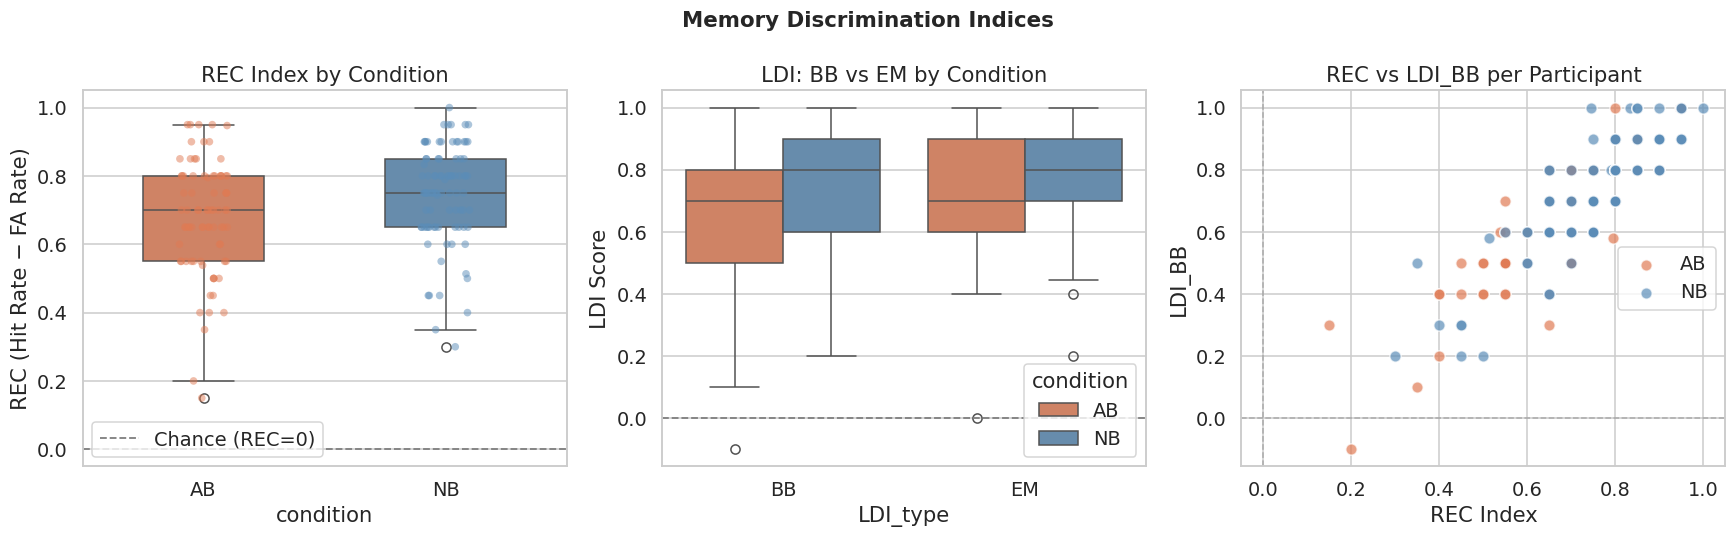

In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# REC by condition
sns.boxplot(data=rec_full, x='condition', y='REC', palette=PALETTE, ax=axes[0],
            order=['AB', 'NB'], width=0.5)
sns.stripplot(data=rec_full, x='condition', y='REC', palette=PALETTE, ax=axes[0],
              order=['AB', 'NB'], size=5, jitter=True, alpha=0.5)
axes[0].axhline(0, color='gray', ls='--', lw=1.2, label='Chance (REC=0)')
axes[0].set_title('REC Index by Condition')
axes[0].set_ylabel('REC (Hit Rate − FA Rate)')
axes[0].legend()

# LDI_BB vs LDI_EM per condition
ldi_long = rec_full.melt(id_vars=['subject_id', 'condition'],
                          value_vars=[c for c in ['LDI_BB', 'LDI_EM'] if c in rec_full.columns],
                          var_name='LDI_type', value_name='LDI_score')
ldi_long['LDI_type'] = ldi_long['LDI_type'].str.replace('LDI_', '')

sns.boxplot(data=ldi_long, x='LDI_type', y='LDI_score', hue='condition',
            palette=PALETTE, ax=axes[1], order=['BB', 'EM'])
axes[1].axhline(0, color='gray', ls='--', lw=1.2)
axes[1].set_title('LDI: BB vs EM by Condition')
axes[1].set_ylabel('LDI Score')

# Scatter: REC vs LDI_BB coloured by condition
for cond in ['AB', 'NB']:
    sub = rec_full[rec_full['condition'] == cond]
    if 'LDI_BB' in sub.columns:
        axes[2].scatter(sub['REC'], sub['LDI_BB'], c=PALETTE[cond], label=cond,
                        alpha=0.7, s=55, edgecolors='white')
axes[2].axhline(0, color='gray', ls='--', lw=1, alpha=0.5)
axes[2].axvline(0, color='gray', ls='--', lw=1, alpha=0.5)
axes[2].set_xlabel('REC Index')
axes[2].set_ylabel('LDI_BB')
axes[2].set_title('REC vs LDI_BB per Participant')
axes[2].legend()

plt.suptitle('Memory Discrimination Indices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


In [41]:
# Statistical tests for REC and LDI indices
def compare_groups(metric, df, col):
    ab = df[df['condition'] == 'AB'][col].dropna()
    nb = df[df['condition'] == 'NB'][col].dropna()
    _, p_a = shapiro(ab) if len(ab) >= 3 else (0, 0)
    _, p_n = shapiro(nb) if len(nb) >= 3 else (0, 0)
    if p_a > 0.05 and p_n > 0.05:
        stat, p = ttest_ind(ab, nb, equal_var=False)
        test = "Welch t"
    else:
        stat, p = mannwhitneyu(ab, nb, alternative='two-sided')
        test = "Mann-Whitney U"
    d = (ab.mean() - nb.mean()) / np.sqrt((ab.std()**2 + nb.std()**2) / 2)
    print(f"{metric:12s}  |  AB: {ab.mean():.3f} ± {ab.std():.3f}  |  "
          f"NB: {nb.mean():.3f} ± {nb.std():.3f}  |  {test}: stat={stat:.3f}, p={p:.4f}, d={d:.3f}")

print(f"{'Metric':12s}  |  {'AB Mean ± SD':22s}  |  {'NB Mean ± SD':22s}  |  Test")
print("─" * 90)
compare_groups('REC',    rec_full, 'REC')
if 'LDI_BB' in rec_full.columns:
    compare_groups('LDI_BB',  rec_full, 'LDI_BB')
if 'LDI_EM' in rec_full.columns:
    compare_groups('LDI_EM',  rec_full, 'LDI_EM')


Metric        |  AB Mean ± SD            |  NB Mean ± SD            |  Test
──────────────────────────────────────────────────────────────────────────────────────────
REC           |  AB: 0.679 ± 0.165  |  NB: 0.745 ± 0.143  |  Mann-Whitney U: stat=2681.500, p=0.0054, d=-0.433
LDI_BB        |  AB: 0.646 ± 0.211  |  NB: 0.722 ± 0.194  |  Mann-Whitney U: stat=2743.000, p=0.0092, d=-0.377
LDI_EM        |  AB: 0.711 ± 0.183  |  NB: 0.768 ± 0.154  |  Mann-Whitney U: stat=2889.500, p=0.0318, d=-0.340


## Section 13: Correlation Analysis

Examining relationships between:
- RT and Accuracy
- Confidence and Accuracy
- Confidence and RT
- REC and mean confidence

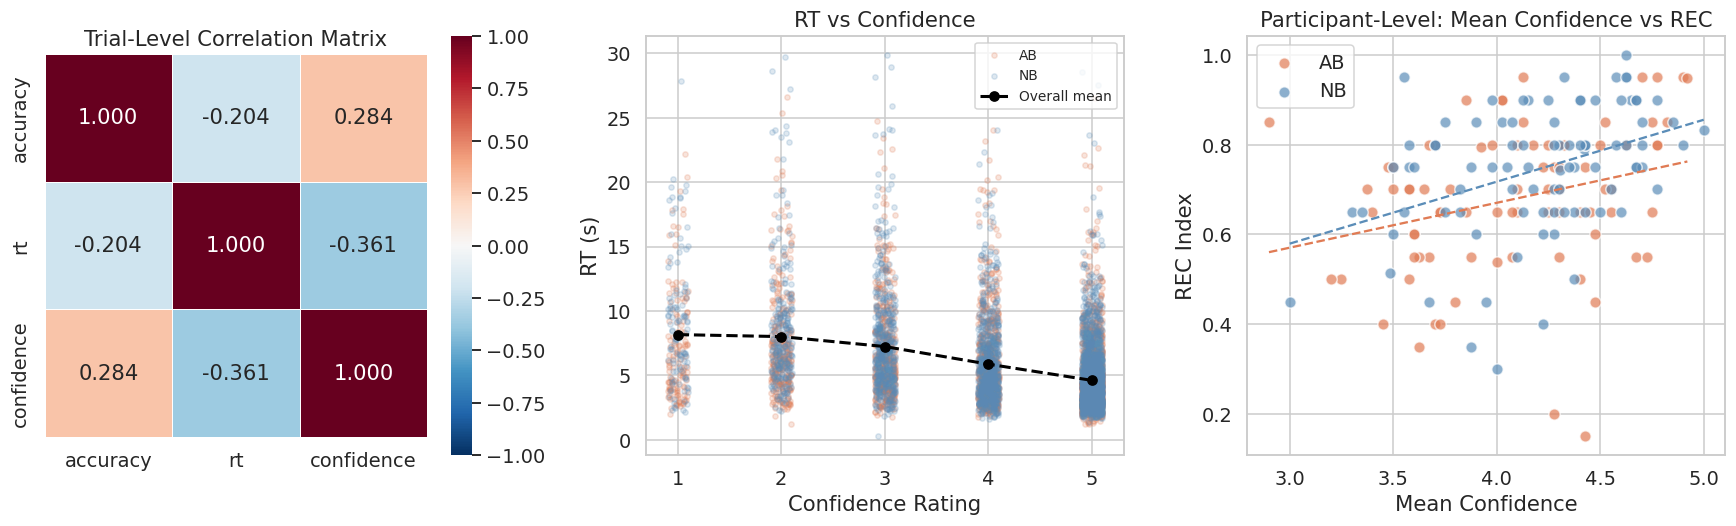


Trial-level correlations (Pearson r and Spearman rho):
  rt × accuracy: Pearson r=-0.204, p=0.0000 | Spearman rho=-0.195, p=0.0000
  confidence × accuracy: Pearson r=0.284, p=0.0000 | Spearman rho=0.272, p=0.0000
  confidence × rt: Pearson r=-0.361, p=0.0000 | Spearman rho=-0.380, p=0.0000


In [42]:
# Trial-level correlations
corr_vars = ['accuracy', 'rt', 'confidence']
corr_matrix = TRIALS_CLEAN[corr_vars].corr()

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Correlation heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            ax=axes[0], square=True, linewidths=0.5, vmin=-1, vmax=1)
axes[0].set_title('Trial-Level Correlation Matrix')

# RT vs Confidence (scatter)
for cond in ['AB', 'NB']:
    sub = TRIALS_CLEAN[TRIALS_CLEAN['condition'] == cond]
    axes[1].scatter(sub['confidence'] + np.random.uniform(-0.1, 0.1, len(sub)),
                    sub['rt'], c=PALETTE[cond], alpha=0.2, s=12, label=cond)
# Add mean line
conf_rt = TRIALS_CLEAN.groupby('confidence', observed=True)['rt'].mean()
axes[1].plot(conf_rt.index, conf_rt.values, 'ko--', lw=2, ms=6, label='Overall mean')
axes[1].set_xlabel('Confidence Rating')
axes[1].set_ylabel('RT (s)')
axes[1].set_title('RT vs Confidence')
axes[1].legend(fontsize=9)

# Participant-level: REC vs mean confidence
subj_conf = TRIALS_CLEAN.groupby(['subject_id', 'condition'], observed=True)['confidence'].mean().reset_index()
subj_conf = subj_conf.rename(columns={'confidence': 'mean_conf'})
rec_conf  = rec_full.merge(subj_conf, on=['subject_id', 'condition'], how='left')
for cond in ['AB', 'NB']:
    sub = rec_conf[rec_conf['condition'] == cond].dropna(subset=['REC', 'mean_conf'])
    axes[2].scatter(sub['mean_conf'], sub['REC'], c=PALETTE[cond], alpha=0.7,
                    s=55, label=cond, edgecolors='white')
    if len(sub) > 2:
        m, b = np.polyfit(sub['mean_conf'], sub['REC'], 1)
        x_line = np.linspace(sub['mean_conf'].min(), sub['mean_conf'].max(), 50)
        axes[2].plot(x_line, m*x_line + b, color=PALETTE[cond], lw=1.5, ls='--')
axes[2].set_xlabel('Mean Confidence')
axes[2].set_ylabel('REC Index')
axes[2].set_title('Participant-Level: Mean Confidence vs REC')
axes[2].legend()

plt.tight_layout()
plt.show()

# Print correlation table
print("\nTrial-level correlations (Pearson r and Spearman rho):")
for v1, v2 in [('rt', 'accuracy'), ('confidence', 'accuracy'), ('confidence', 'rt')]:
    pair_df = TRIALS_CLEAN[[v1, v2]].dropna()
    r_pearson, p_pearson = pearsonr(pair_df[v1], pair_df[v2])
    rho_spearman, p_spearman = stats.spearmanr(pair_df[v1], pair_df[v2])
    print(
        f"  {v1} × {v2}: "
        f"Pearson r={r_pearson:.3f}, p={p_pearson:.4f} | "
        f"Spearman rho={rho_spearman:.3f}, p={p_spearman:.4f}"
    )


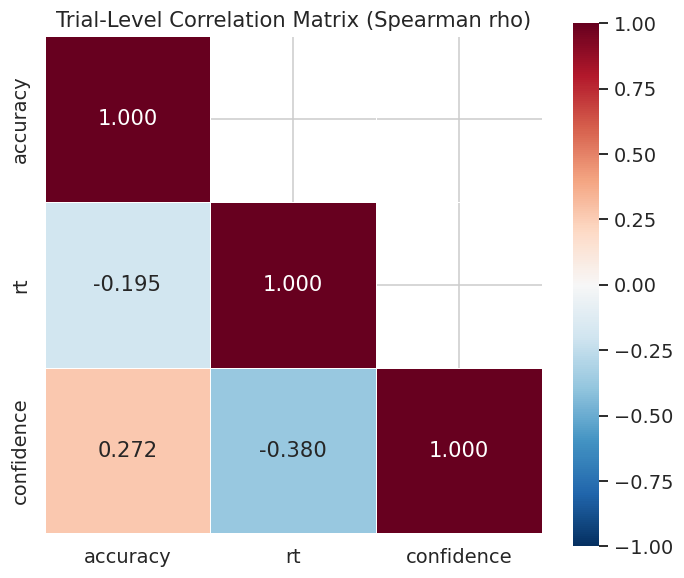

In [43]:
# Spearman correlation heatmap (rank-based)
corr_vars = ['accuracy', 'rt', 'confidence']
corr_matrix_spearman = TRIALS_CLEAN[corr_vars].corr(method='spearman')

plt.figure(figsize=(6.5, 5.5))
mask = np.triu(np.ones_like(corr_matrix_spearman, dtype=bool), k=1)
sns.heatmap(corr_matrix_spearman, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, vmin=-1, vmax=1, mask=mask)
plt.title('Trial-Level Correlation Matrix (Spearman rho)')
plt.tight_layout()
plt.show()


## Section 14: Stimulus-Level Analysis

Which individual videos are hardest or easiest to remember? Checking for item-level variance that could be a confound.

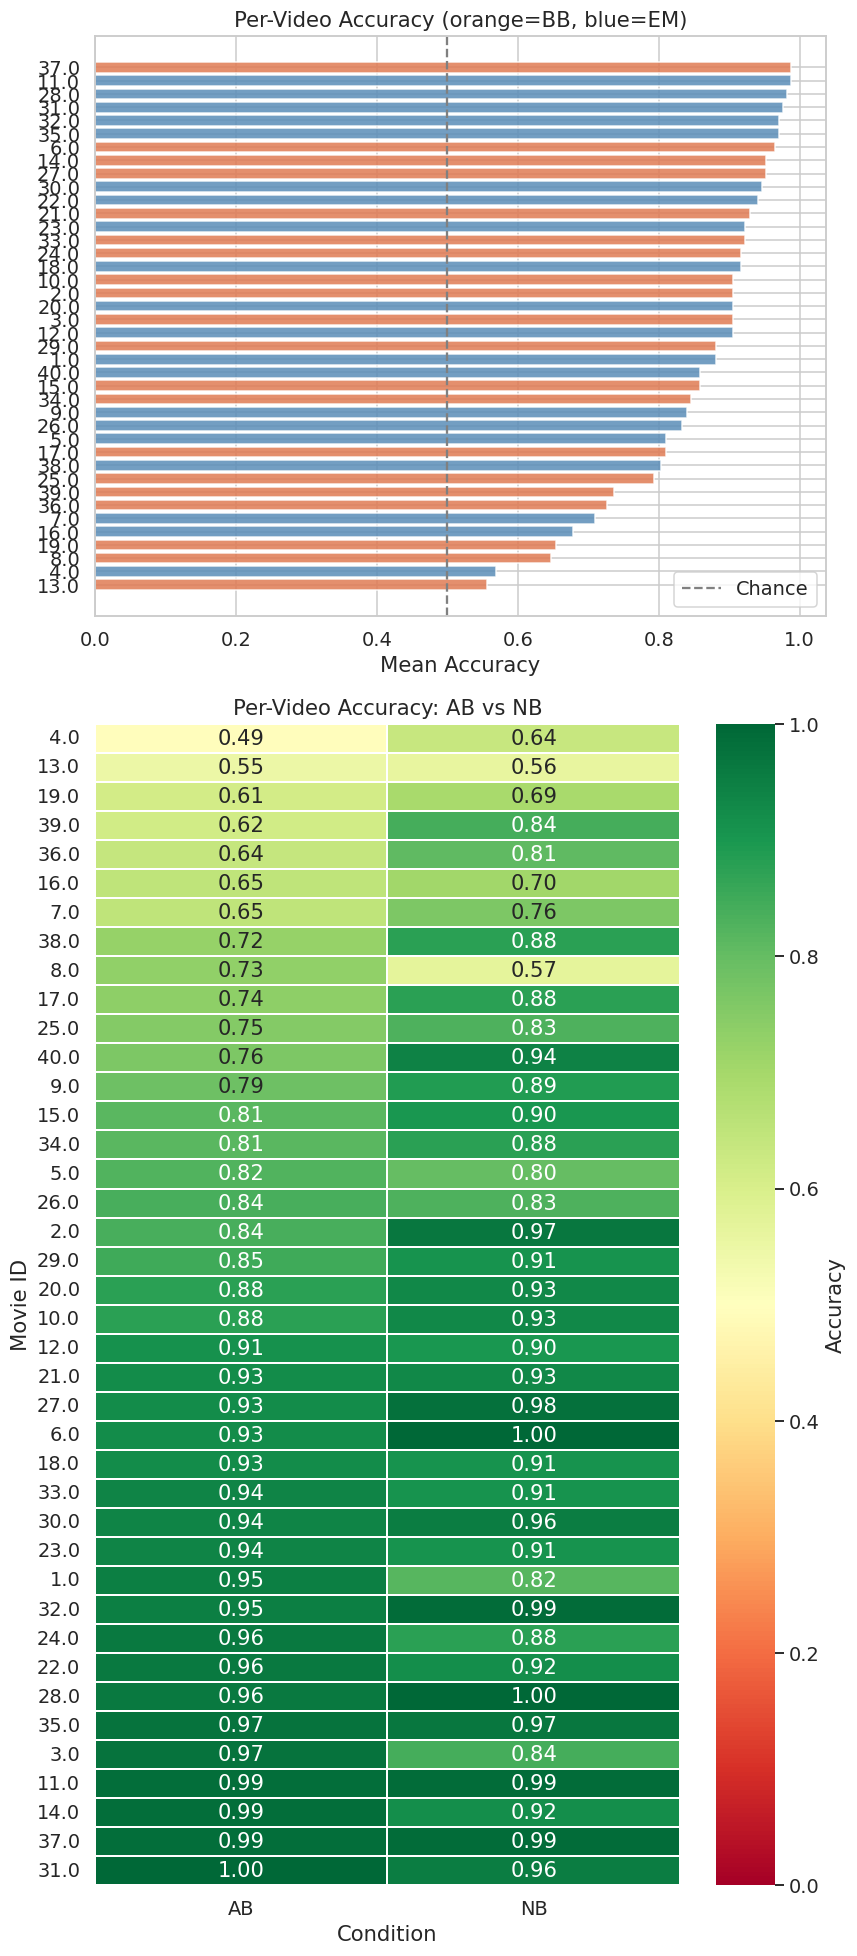


Video accuracy summary across conditions:
      mean_acc
min     0.5560
max     0.9880
mean    0.8570
std     0.1160


In [44]:
# Per-video accuracy
video_acc = (TRIALS_CLEAN.groupby(['movie_id', 'target_type', 'condition'], observed=True)
             .agg(mean_acc=('accuracy', 'mean'), n=('accuracy', 'count'))
             .reset_index()
             .sort_values('mean_acc'))

# create a vertically elongated layout: bar chart on top, heatmap below
fig, axes = plt.subplots(2, 1, figsize=(8, 18), gridspec_kw={'height_ratios':[1,2]})

# Overall per-video accuracy (collapsed across conditions)
video_overall = (TRIALS_CLEAN.groupby('movie_id', observed=True)
                 .agg(mean_acc=('accuracy', 'mean'), n=('accuracy', 'count'))
                 .reset_index()
                 .sort_values('mean_acc'))

colors_vid = ['#E07B54' if mid in df_tl[df_tl['target_type']=='BB']['movie_id'].values
              else '#5B8DB8' for mid in video_overall['movie_id']]

axes[0].barh(video_overall['movie_id'].astype(str), video_overall['mean_acc'],
             color=colors_vid, edgecolor='white', alpha=0.85)
axes[0].axvline(0.5, color='gray', ls='--', lw=1.5, label='Chance')
axes[0].set_xlabel('Mean Accuracy')
axes[0].set_title('Per-Video Accuracy (orange=BB, blue=EM)')
axes[0].legend()

# Accuracy per video × condition heatmap (larger vertical space)
heat_data = (TRIALS_CLEAN.groupby(['movie_id', 'condition'], observed=True)['accuracy']
             .mean().unstack('condition').sort_values('AB' if 'AB' in video_overall.columns else 'AB'))

sns.heatmap(heat_data, annot=True, fmt='.2f', cmap='RdYlGn', center=0.5,
            vmin=0, vmax=1, ax=axes[1], linewidths=0.3,
            cbar_kws={'label': 'Accuracy'})
axes[1].set_title('Per-Video Accuracy: AB vs NB')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Movie ID')

# improve layout to prevent overlap
plt.tight_layout()


plt.tight_layout()
plt.show()

print("\nVideo accuracy summary across conditions:")
print(video_overall[['movie_id', 'mean_acc', 'n']].agg({'mean_acc': ['min', 'max', 'mean', 'std']}).round(3))


## Section 15: Individual Differences

Visualising participant-level variability to detect outlier participants.

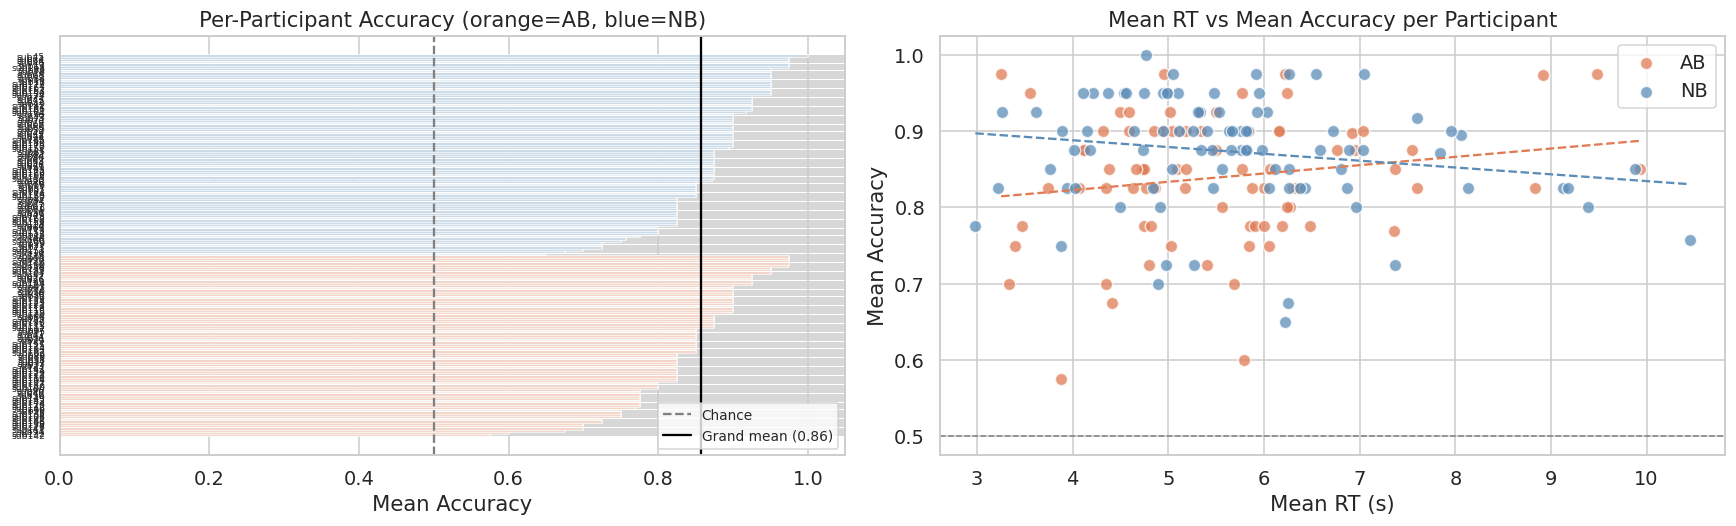

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Per-participant accuracy sorted
subj_sorted = subj_df.sort_values(['condition', 'mean_accuracy'])
colors_sub  = [PALETTE[c] for c in subj_sorted['condition']]
axes[0].barh(range(len(subj_sorted)), subj_sorted['mean_accuracy'],
             color=colors_sub, edgecolor='white', alpha=0.85)
axes[0].axvline(0.5,  color='gray', ls='--', lw=1.5, label='Chance')
axes[0].axvline(subj_sorted['mean_accuracy'].mean(), color='black', ls='-', lw=1.5,
                label=f'Grand mean ({subj_sorted["mean_accuracy"].mean():.2f})')
axes[0].set_yticks(range(len(subj_sorted)))
axes[0].set_yticklabels(subj_sorted['subject_id'].astype(str), fontsize=6)
axes[0].set_xlabel('Mean Accuracy')
axes[0].set_title('Per-Participant Accuracy (orange=AB, blue=NB)')
axes[0].legend(fontsize=9)

# Scatter: accuracy vs RT per participant coloured by condition
for cond in ['AB', 'NB']:
    sub = subj_df[subj_df['condition'] == cond]
    axes[1].scatter(sub['mean_rt'], sub['mean_accuracy'],
                    c=PALETTE[cond], s=65, alpha=0.75, label=cond, edgecolors='white')
    # Regression line
    if len(sub) > 2:
        m, b = np.polyfit(sub['mean_rt'], sub['mean_accuracy'], 1)
        xr = np.linspace(sub['mean_rt'].min(), sub['mean_rt'].max(), 50)
        axes[1].plot(xr, m*xr + b, color=PALETTE[cond], lw=1.5, ls='--')

axes[1].axhline(0.5, color='gray', ls='--', lw=1)
axes[1].set_xlabel('Mean RT (s)')
axes[1].set_ylabel('Mean Accuracy')
axes[1].set_title('Mean RT vs Mean Accuracy per Participant')
axes[1].legend()

plt.tight_layout()
plt.show()


## Section 16: Feature Encoding & Scaling

Encoding categorical variables and normalising continuous features for use in downstream statistical models.

In [46]:
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

MODEL_DF = TRIALS_CLEAN[['subject_id', 'condition', 'target_type', 'accuracy', 'rt', 'confidence', 'movie_id']].copy()

# ── Label Encoding (for models that need numeric categories) ──────────────
le_cond = LabelEncoder()
le_type = LabelEncoder()
MODEL_DF['condition_enc']    = le_cond.fit_transform(MODEL_DF['condition'].astype(str))
# Ensure target_type is converted to object dtype before filling missing values
# This avoids a pandas TypeError when target_type is a Categorical and we try to
# fill it with a value that is not already in its categories.
MODEL_DF['target_type_enc'] = le_type.fit_transform(
    MODEL_DF['target_type'].astype('object').fillna('Unknown')
)

print(f"Shape after encoding: {MODEL_DF.shape}")
print(f"Label encodings:")
print(f"  condition:   {dict(zip(le_cond.classes_, le_cond.transform(le_cond.classes_)))}")
print(f"  target_type: {dict(zip(le_type.classes_, le_type.transform(le_type.classes_)))}")

# ── One-Hot Encoding ──────────────────────────────────────────────────────
MODEL_OHE = pd.get_dummies(MODEL_DF, columns=['condition', 'target_type'], drop_first=False)
print(f"\nAfter One-Hot Encoding shape: {MODEL_OHE.shape}")
print("New OHE columns:", [c for c in MODEL_OHE.columns if 'condition_' in c or 'target_type_' in c])

# ── Standard Scaling ──────────────────────────────────────────────────────
scaler_std = StandardScaler()
MODEL_DF['rt_zscore'] = scaler_std.fit_transform(MODEL_DF[['rt']])

# ── Min-Max Scaling ───────────────────────────────────────────────────────
scaler_mm = MinMaxScaler()
MODEL_DF['confidence_norm'] = scaler_mm.fit_transform(MODEL_DF[['confidence']])
MODEL_DF['rt_norm']         = scaler_mm.fit_transform(MODEL_DF[['rt']])

print(f"\nScaling applied. Sample:")
print(MODEL_DF[['rt', 'rt_zscore', 'rt_norm', 'confidence', 'confidence_norm']].describe().round(3))


Shape after encoding: (6746, 9)
Label encodings:
  condition:   {'AB': np.int64(0), 'NB': np.int64(1)}
  target_type: {'BB': np.int64(0), 'EM': np.int64(1)}

After One-Hot Encoding shape: (6746, 11)
New OHE columns: ['condition_enc', 'target_type_enc', 'condition_AB', 'condition_NB', 'target_type_BB', 'target_type_EM']

Scaling applied. Sample:
             rt  rt_zscore   rt_norm  confidence  confidence_norm
count 6746.0000  6746.0000 6746.0000   6746.0000        6746.0000
mean     5.6210    -0.0000    0.1810      4.1460           0.7860
std      3.4350     1.0000    0.1160      1.1370           0.2840
min      0.2760    -1.5560    0.0000      1.0000           0.0000
25%      3.3770    -0.6530    0.1050      4.0000           0.7500
50%      4.6180    -0.2920    0.1470      5.0000           1.0000
75%      6.6840     0.3090    0.2160      5.0000           1.0000
max     29.8770     7.0610    1.0000      5.0000           1.0000


## Section 17: EDA Summary Dashboard

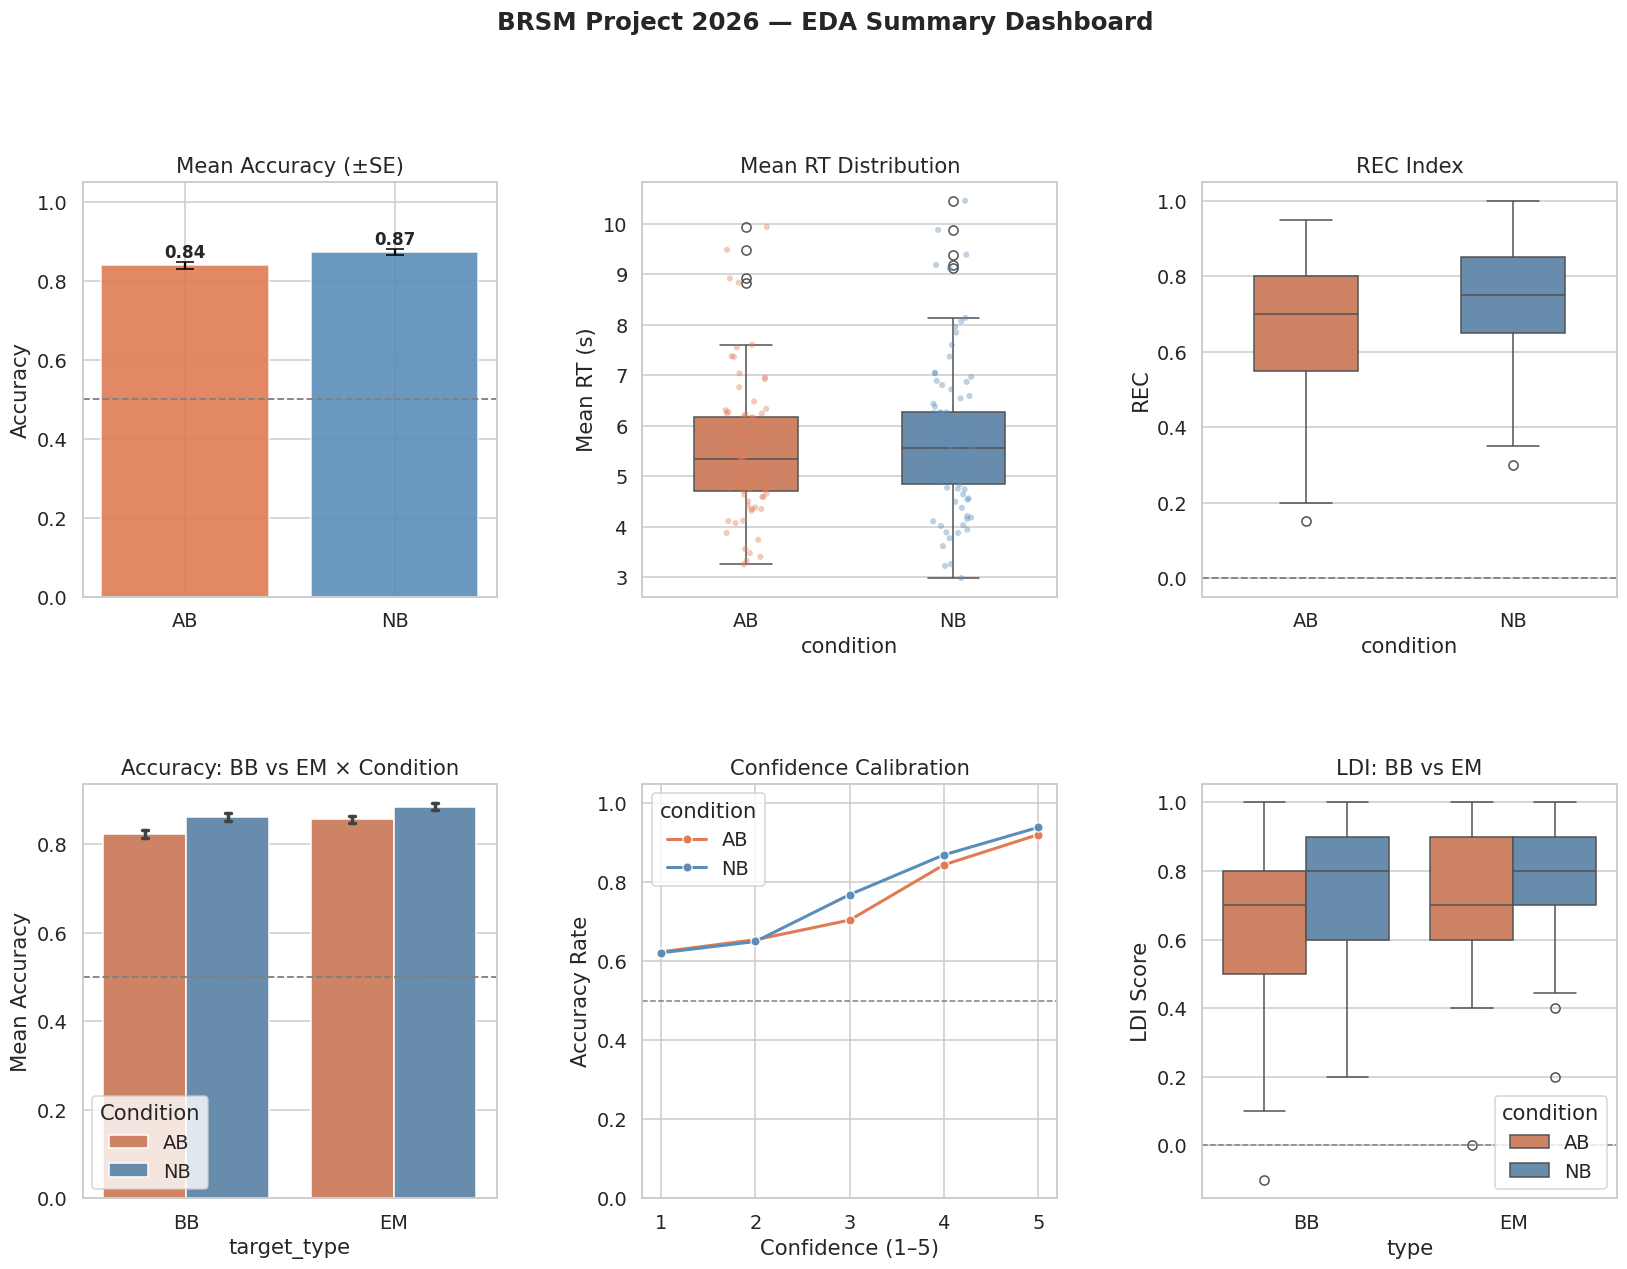

Dashboard saved to BRSM_EDA_Summary_Dashboard.png


In [47]:
fig = plt.figure(figsize=(18, 12))
fig.suptitle('BRSM Project 2026 — EDA Summary Dashboard', fontsize=16, fontweight='bold', y=1.01)

gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# 1. Accuracy by condition
ax1 = fig.add_subplot(gs[0, 0])
means = subj_df.groupby('condition', observed=True)['mean_accuracy'].mean()
sds   = subj_df.groupby('condition', observed=True)['mean_accuracy'].sem()
bars  = ax1.bar(means.index, means.values, yerr=sds.values,
                color=[PALETTE[c] for c in means.index],
                capsize=6, edgecolor='white', alpha=0.9)
ax1.axhline(0.5, color='gray', ls='--', lw=1.2)
ax1.set_ylim(0, 1.05)
ax1.set_title('Mean Accuracy (±SE)')
ax1.set_ylabel('Accuracy')
for bar, val in zip(bars, means.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', fontsize=11, fontweight='bold')

# 2. RT by condition
ax2 = fig.add_subplot(gs[0, 1])
sns.boxplot(data=subj_df, x='condition', y='mean_rt', palette=PALETTE, ax=ax2,
            order=['AB', 'NB'], width=0.5)
sns.stripplot(data=subj_df, x='condition', y='mean_rt', palette=PALETTE, ax=ax2,
              order=['AB', 'NB'], size=4, jitter=True, alpha=0.4)
ax2.set_title('Mean RT Distribution')
ax2.set_ylabel('Mean RT (s)')

# 3. REC by condition
ax3 = fig.add_subplot(gs[0, 2])
sns.boxplot(data=rec_full, x='condition', y='REC', palette=PALETTE, ax=ax3,
            order=['AB', 'NB'], width=0.5)
ax3.axhline(0, color='gray', ls='--', lw=1.2)
ax3.set_title('REC Index')
ax3.set_ylabel('REC')

# 4. Accuracy × Target Type × Condition
ax4 = fig.add_subplot(gs[1, 0])
sns.barplot(data=TRIALS_CLEAN, x='target_type', y='accuracy', hue='condition',
            palette=PALETTE, ax=ax4, capsize=0.06, order=['BB', 'EM'],
            errorbar='se')
ax4.axhline(0.5, color='gray', ls='--', lw=1.2)
ax4.set_title('Accuracy: BB vs EM × Condition')
ax4.set_ylabel('Mean Accuracy')
ax4.legend(title='Condition')

# 5. Confidence calibration
ax5 = fig.add_subplot(gs[1, 1])
calib2 = TRIALS_CLEAN.groupby(['confidence', 'condition'], observed=True)['accuracy'].mean().reset_index()
sns.lineplot(data=calib2, x='confidence', y='accuracy', hue='condition',
             palette=PALETTE, marker='o', lw=2, ax=ax5)
ax5.axhline(0.5, color='gray', ls='--', lw=1)
ax5.set_title('Confidence Calibration')
ax5.set_xlabel('Confidence (1–5)')
ax5.set_ylabel('Accuracy Rate')
ax5.set_ylim(0, 1.05)

# 6. LDI BB vs EM
ax6 = fig.add_subplot(gs[1, 2])
if 'LDI_BB' in rec_full.columns and 'LDI_EM' in rec_full.columns:
    ldi_l = rec_full.melt(id_vars=['condition'],
                           value_vars=['LDI_BB', 'LDI_EM'],
                           var_name='type', value_name='LDI')
    ldi_l['type'] = ldi_l['type'].str.replace('LDI_', '')
    sns.boxplot(data=ldi_l, x='type', y='LDI', hue='condition',
                palette=PALETTE, ax=ax6, order=['BB', 'EM'])
    ax6.axhline(0, color='gray', ls='--', lw=1)
    ax6.set_title('LDI: BB vs EM')
    ax6.set_ylabel('LDI Score')
else:
    ax6.text(0.5, 0.5, 'LDI data\nnot available', ha='center', va='center',
             transform=ax6.transAxes, fontsize=12)

plt.savefig('BRSM_EDA_Summary_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard saved to BRSM_EDA_Summary_Dashboard.png")


## Section 18: Save Cleaned Data

In [48]:
OUTPUT_DIR = os.path.join(os.path.dirname(os.path.abspath('BRSM_EDA.ipynb')), 'BRSM_cleaned_outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

# 1. Clean trial-level data
trial_out_cols = ['subject_id', 'condition', 'movie_id', 'target_type',
                  'accuracy', 'rt', 'log_rt', 'confidence',
                  'condition_enc', 'target_type_enc',
                  'rt_zscore', 'rt_norm', 'confidence_norm']
trial_out_cols_avail = [c for c in trial_out_cols if c in MODEL_DF.columns]
clean_trials = MODEL_DF[trial_out_cols_avail].copy()
clean_trials.to_csv(os.path.join(OUTPUT_DIR, 'BRSM_clean_trials.csv'), index=False)
print(f"✓ Saved: BRSM_clean_trials.csv  ({len(clean_trials):,} rows)")

# 2. Per-participant summary
subj_summary = subj_df.merge(
    rec_full[['subject_id', 'condition', 'REC'] + [c for c in ['LDI_BB', 'LDI_EM'] if c in rec_full.columns]],
    on=['subject_id', 'condition'], how='left'
)
subj_summary.to_csv(os.path.join(OUTPUT_DIR, 'BRSM_participant_summary.csv'), index=False)
print(f"✓ Saved: BRSM_participant_summary.csv  ({len(subj_summary)} participants)")

# 3. Per-video accuracy
video_acc.to_csv(os.path.join(OUTPUT_DIR, 'BRSM_video_accuracy.csv'), index=False)
print(f"✓ Saved: BRSM_video_accuracy.csv  ({len(video_acc)} video-condition rows)")

# 4. Vigilance log
df_vig.to_csv(os.path.join(OUTPUT_DIR, 'BRSM_vigilance_log.csv'), index=False)
print(f"✓ Saved: BRSM_vigilance_log.csv")

print(f"\nAll outputs saved to: {OUTPUT_DIR}")
print("\n── Final Dataset Summary ──────────────────────────────────────")
print(f"  Participants (clean):  {clean_trials['subject_id'].nunique()}")
print(f"  Trials (clean):        {len(clean_trials):,}")
print(f"  AB participants:       {(subj_summary['condition']=='AB').sum()}")
print(f"  NB participants:       {(subj_summary['condition']=='NB').sum()}")
print(f"  Trials per subject:    {len(clean_trials) / clean_trials['subject_id'].nunique():.1f} avg")


✓ Saved: BRSM_clean_trials.csv  (6,746 rows)
✓ Saved: BRSM_participant_summary.csv  (169 participants)
✓ Saved: BRSM_video_accuracy.csv  (80 video-condition rows)
✓ Saved: BRSM_vigilance_log.csv

All outputs saved to: /home/sparsh-bhartia/Documents/brsm/project/Break-Fast_BRSM_Project/BRSM_cleaned_outputs

── Final Dataset Summary ──────────────────────────────────────
  Participants (clean):  169
  Trials (clean):        6,746
  AB participants:       80
  NB participants:       89
  Trials per subject:    39.9 avg


### Z-Score Analysis
Here, I will calculate the z-scores for the accuracy of each group. This will show how each group's performance deviates from the mean performance of all participants.

Participant-level Z-scores:
    subject_id condition  accuracy  accuracy_zscore
0       sub100        AB    0.9750           1.5064
1       sub101        AB    0.8250          -0.4059
2       sub102        AB    0.8500          -0.0872
3       sub103        AB    0.8500          -0.0872
4       sub104        AB    0.8250          -0.4059
..         ...       ...       ...              ...
164      sub95        AB    0.8500          -0.0872
165      sub96        AB    0.7750          -1.0433
166      sub97        AB    0.8500          -0.0872
167      sub98        AB    0.7500          -1.3620
168      sub99        AB    0.8250          -0.4059

[169 rows x 4 columns]

Mean Z-scores by Group:
  condition  accuracy_zscore
0        AB          -0.2241
1        NB           0.2015


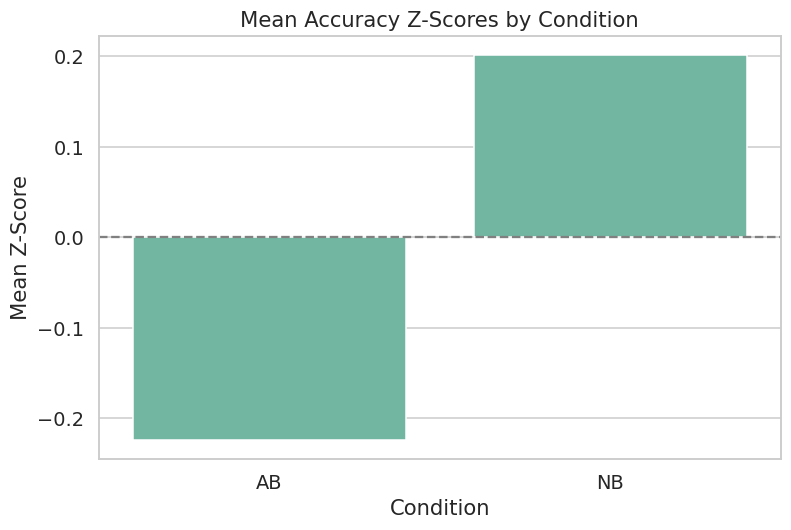

In [49]:
# Calculate accuracy for each participant
participant_accuracy = TRIALS_CLEAN.groupby('subject_id')['accuracy'].mean().reset_index()

# Merge with condition information
participant_summary_with_condition = pd.merge(participant_accuracy, df_demo[['subject_id', 'condition']], on='subject_id')

# Calculate overall mean and standard deviation of accuracy
overall_mean_accuracy = participant_summary_with_condition['accuracy'].mean()
overall_std_accuracy = participant_summary_with_condition['accuracy'].std()

# Calculate z-scores for each participant
participant_summary_with_condition['accuracy_zscore'] = (participant_summary_with_condition['accuracy'] - overall_mean_accuracy) / overall_std_accuracy

# Display z-scores per participant
print("Participant-level Z-scores:")
print(participant_summary_with_condition[['subject_id', 'condition', 'accuracy', 'accuracy_zscore']])

# Calculate and display the mean z-score for each group
group_z_scores = participant_summary_with_condition.groupby('condition')['accuracy_zscore'].mean().reset_index()

print("\nMean Z-scores by Group:")
print(group_z_scores)

# Plot the group z-scores
plt.figure(figsize=(8, 5))
sns.barplot(x='condition', y='accuracy_zscore', data=group_z_scores)
plt.title('Mean Accuracy Z-Scores by Condition')
plt.xlabel('Condition')
plt.ylabel('Mean Z-Score')
plt.axhline(0, color='grey', linestyle='--')
plt.show()

### D-Prime Analysis (Signal Detection Theory)

D-prime (d') is a measure of sensitivity from signal detection theory. It quantifies the ability to distinguish between signal (target videos) and noise (lure videos).

*   **Hits**: Correctly identifying a target video ("old").
*   **Misses**: Incorrectly identifying a target video as "new".
*   **False Alarms**: Incorrectly identifying a lure video as "old".
*   **Correct Rejections**: Correctly identifying a lure video as "new".

I'll calculate d' and the response bias (criterion c) for each participant and then compare these measures between the AB and NB groups.

Signal Detection Theory (d' and c) Summary:
  subject_id condition  d_prime  criterion_c
0     sub100        AB   3.9199      -0.0000
1     sub101        AB   1.8692      -0.0000
2     sub102        AB   2.0729      -0.0000
3     sub103        AB   2.0729      -0.0000
4     sub104        AB   1.8692      -0.0000
5     sub105        AB   1.3490      -0.0000
6     sub106        AB   1.1955      -0.0000
7     sub107        AB   3.2897      -0.0000
8     sub108        AB   1.3490      -0.0000
9     sub109        AB   1.6832      -0.0000

D-Prime Statistics by Condition:
          d_prime                                                   \
            count   mean    std    min    25%    50%    75%    max   
condition                                                            
AB        80.0000 2.1170 0.7560 0.3780 1.5110 2.0730 2.5630 3.9200   
NB        89.0000 2.4240 0.7390 0.7710 1.8690 2.3010 2.8790 4.4830   

          criterion_c                                                       

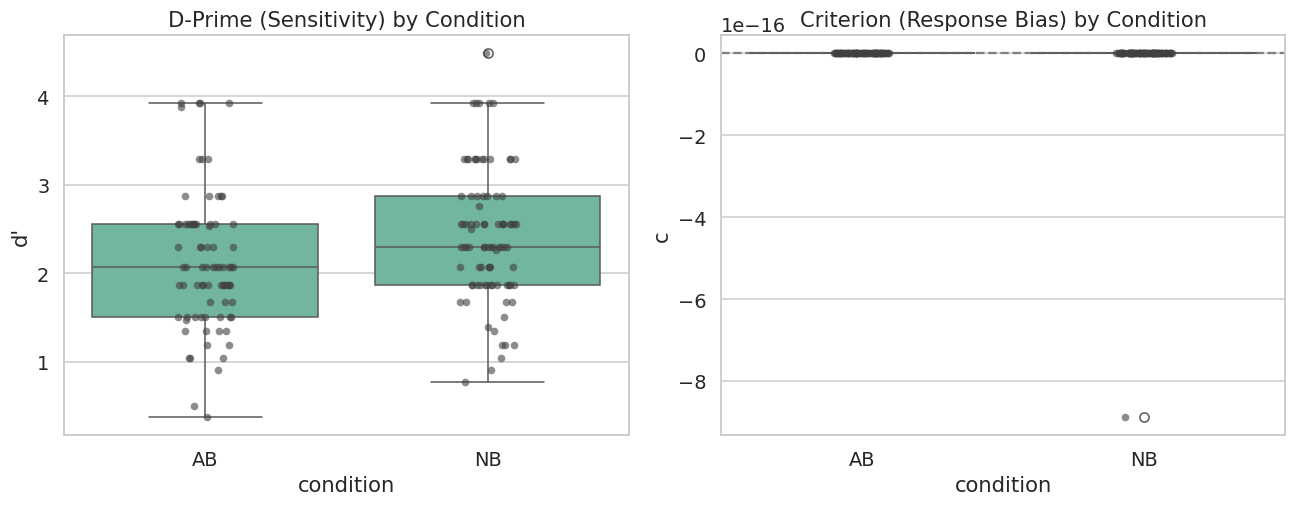

In [50]:
from scipy.stats import norm
import numpy as np

# For d-prime calculation, we need hit rate and false alarm rate per participant
# We'll use accuracy (which is already calculated) and calculate based on correct/incorrect responses

# Calculate hit rate (accuracy) and false alarm rate per participant
dprime_summary = TRIALS_CLEAN.groupby('subject_id').agg(
    accuracy = ('accuracy', 'mean'),
    n_trials = ('accuracy', 'count'),
).reset_index()

# In a recognition task: hit_rate = accuracy, fa_rate = (1 - accuracy) for lures/foils
# We'll treat accuracy as hit rate and use (1 - accuracy) as complement
dprime_summary['hit_rate'] = dprime_summary['accuracy']
dprime_summary['fa_rate'] = 1 - dprime_summary['accuracy']

# Adjust for extreme values (0 or 1) using the log-linear rule
def adjust_rate(rate, n):
    return np.clip(rate, 1/(2*n), 1 - 1/(2*n))

dprime_summary['hit_rate_adj'] = dprime_summary.apply(
    lambda row: adjust_rate(row['hit_rate'], row['n_trials']), axis=1
)
dprime_summary['fa_rate_adj'] = dprime_summary.apply(
    lambda row: adjust_rate(row['fa_rate'], row['n_trials']), axis=1
)

# Calculate d-prime and criterion c using adjusted rates
Z = norm.ppf
dprime_summary['d_prime'] = Z(dprime_summary['hit_rate_adj']) - Z(dprime_summary['fa_rate_adj'])
dprime_summary['criterion_c'] = -0.5 * (Z(dprime_summary['hit_rate_adj']) + Z(dprime_summary['fa_rate_adj']))

# Merge with condition info
dprime_summary = dprime_summary.merge(df_demo[['subject_id', 'condition']], on='subject_id')

print("Signal Detection Theory (d' and c) Summary:")
print(dprime_summary[['subject_id', 'condition', 'd_prime', 'criterion_c']].head(10))

print("\nD-Prime Statistics by Condition:")
print(dprime_summary.groupby('condition')[['d_prime', 'criterion_c']].describe().round(3))

# --- Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# D-prime plot
sns.boxplot(x='condition', y='d_prime', data=dprime_summary, ax=axes[0])
sns.stripplot(x='condition', y='d_prime', data=dprime_summary, color=".25", alpha=0.6, ax=axes[0])
axes[0].set_title("D-Prime (Sensitivity) by Condition")
axes[0].set_ylabel("d'")

# Criterion c plot
sns.boxplot(x='condition', y='criterion_c', data=dprime_summary, ax=axes[1])
sns.stripplot(x='condition', y='criterion_c', data=dprime_summary, color=".25", alpha=0.6, ax=axes[1])
axes[1].set_title("Criterion (Response Bias) by Condition")
axes[1].set_ylabel("c")
axes[1].axhline(0, color='grey', linestyle='--')

plt.tight_layout()
plt.show()


### Generalized Linear Model (GLM) Analysis

To get a more robust statistical model of the factors influencing memory performance, I will use a Generalized Linear Model (GLM). Specifically, I'll use logistic regression, since the outcome of each trial (correct or incorrect) is binary.

The model will assess the impact of:
*   **Condition** (AB vs. NB)
*   **Stimulus Type** (Target vs. Lure)
*   The **interaction** between condition and stimulus type.

This will help determine if the experimental condition significantly predicts the likelihood of a correct response, while controlling for whether the video was a target or a lure.

Optimization terminated successfully.
         Current function value: 0.408785
         Iterations 6
GENERALIZED LINEAR MODEL (LOGISTIC REGRESSION)
                           Logit Regression Results                           
Dep. Variable:               accuracy   No. Observations:                 6746
Model:                          Logit   Df Residuals:                     6742
Method:                           MLE   Df Model:                            3
Date:                Fri, 17 Apr 2026   Pseudo R-squ.:                0.004718
Time:                        18:48:18   Log-Likelihood:                -2757.7
converged:                       True   LL-Null:                       -2770.7
Covariance Type:            nonrobust   LLR p-value:                 8.902e-06
                                              coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------
Int

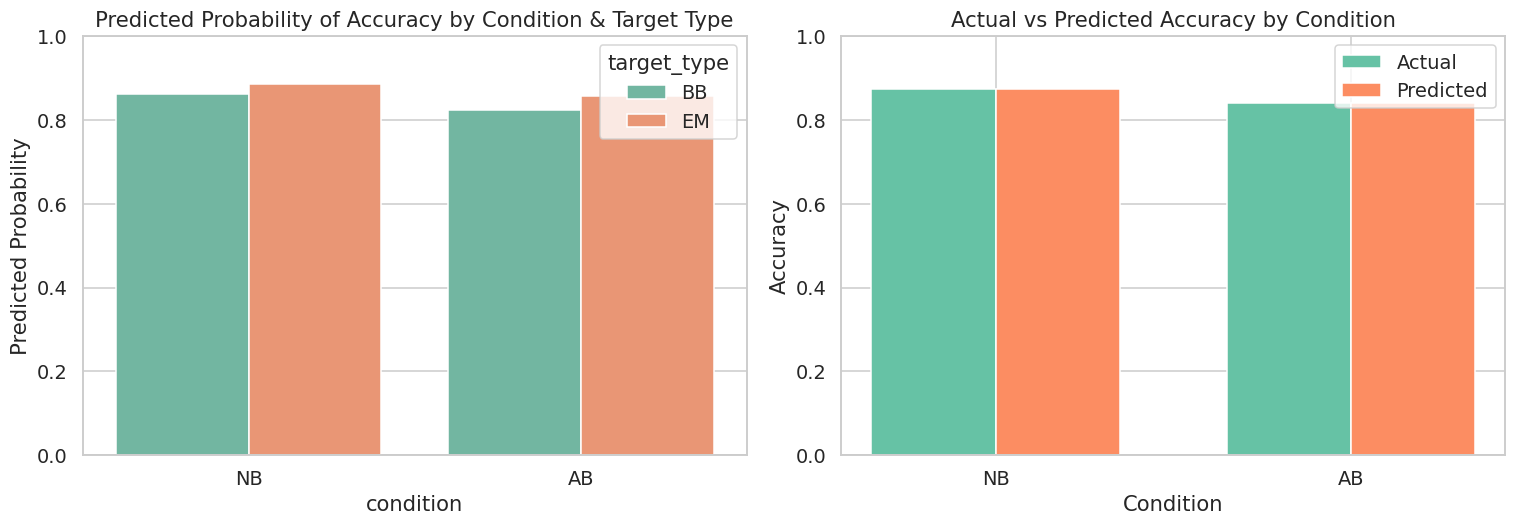


GLM analysis complete!


In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats

# Prepare TRIALS_CLEAN if not already defined (using TRIALS as base)
if 'TRIALS_CLEAN' not in locals():
    print("Creating TRIALS_CLEAN from TRIALS...")
    TRIALS_CLEAN = TRIALS.dropna(subset=['accuracy', 'rt', 'confidence']).copy()
    TRIALS_CLEAN = TRIALS_CLEAN.drop_duplicates(subset=['subject_id', 'movie_id'], keep='first')
    print(f"TRIALS_CLEAN shape: {TRIALS_CLEAN.shape}")

# Prepare the data for the GLM model
glm_data = TRIALS_CLEAN.copy()

# Ensure 'condition' and 'target_type' are treated as categorical
glm_data['condition'] = glm_data['condition'].astype('category')
glm_data['target_type'] = glm_data['target_type'].astype('category')

# Set reference categories for interpretation
glm_data['condition'] = glm_data['condition'].cat.reorder_categories(['NB', 'AB'])  # NB as reference
glm_data['target_type'] = glm_data['target_type'].cat.reorder_categories(['BB', 'EM'])  # BB as reference

# ── Generalized Linear Model: Logistic Regression ────────────────────────────
# Predicting accuracy (binary: correct=1, incorrect=0) based on condition, stimulus type, and their interaction
formula = "accuracy ~ C(condition) * C(target_type)"

# Fit as logistic regression (GLM with Binomial family)
glm_model = smf.logit(formula=formula, data=glm_data).fit()

print("=" * 80)
print("GENERALIZED LINEAR MODEL (LOGISTIC REGRESSION)")
print("=" * 80)
print(glm_model.summary())

# ── Model Statistics ────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("MODEL STATISTICS")
print("=" * 80)
print(f"Pseudo R-squared (McFadden): {glm_model.prsquared:.4f}")
print(f"Log-Likelihood: {glm_model.llf:.2f}")
print(f"AIC: {glm_model.aic:.2f}")
print(f"BIC: {glm_model.bic:.2f}")

# ── Odds Ratios ────────────────────────────────────────────────────────────
print("\n" + "=" * 80)
print("ODDS RATIOS (Exponentiated Coefficients)")
print("=" * 80)
odds_ratios = np.exp(glm_model.params)
conf_int = np.exp(glm_model.conf_int())
odds_summary = pd.DataFrame({
    'Odds Ratio': odds_ratios,
    'Lower CI': conf_int[0],
    'Upper CI': conf_int[1]
})
print(odds_summary.round(4))

# ── Predictions and Model Performance ────────────────────────────────────────
glm_data['predicted_prob'] = glm_model.predict(glm_data)
glm_data['predicted_accuracy'] = (glm_data['predicted_prob'] >= 0.5).astype(int)

# Calculate accuracy of predictions
model_accuracy = (glm_data['predicted_accuracy'] == glm_data['accuracy']).mean()
print(f"\nModel Prediction Accuracy: {model_accuracy:.4f}")

# ── Visualization of Model Predictions ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predicted Probabilities by Condition and Target Type
pred_data = glm_data.groupby(['condition', 'target_type'])['predicted_prob'].mean().reset_index()
sns.barplot(x='condition', y='predicted_prob', hue='target_type', data=pred_data, ax=axes[0])
axes[0].set_title('Predicted Probability of Accuracy by Condition & Target Type')
axes[0].set_ylabel('Predicted Probability')
axes[0].set_ylim([0, 1])

# Plot 2: Actual vs Predicted by Condition
actual_vs_pred = glm_data.groupby('condition').agg(
    actual_accuracy = ('accuracy', 'mean'),
    predicted_accuracy = ('predicted_prob', 'mean')
).reset_index()
x = np.arange(len(actual_vs_pred))
width = 0.35
axes[1].bar(x - width/2, actual_vs_pred['actual_accuracy'], width, label='Actual')
axes[1].bar(x + width/2, actual_vs_pred['predicted_accuracy'], width, label='Predicted')
axes[1].set_xlabel('Condition')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Actual vs Predicted Accuracy by Condition')
axes[1].set_xticks(x)
axes[1].set_xticklabels(actual_vs_pred['condition'])
axes[1].legend()
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

print("\nGLM analysis complete!")
